In [ ]:
!pip install optuna catboost xgboost lightgbm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from scipy import stats
from sklearn import metrics
from sklearn.model_selection import cross_val_score
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor

import shap

In [ ]:
data_original = pd.read_excel('regression_avito_deals.xlsx')
data_original = data_original.sample(50000, random_state = 42)
data_original

,item_id,user_id,region,city,parent_category_name,category_name,param_1,param_2,param_3,title,description,price,item_seq_number,activation_date,user_type,deal_probability
279102,7c44a2a9f528,f118b45be716,Татарстан,Казань,Услуги,Предложение услуг,"Ремонт, строительство","Строительство бань, саун",NaN,Банные печи,Банные печи в наличии и под заказ скамейки 1 ...,8000.0,2,2017-03-21,Private,0.20000
332542,64110351080d,ab7907eaf4b3,Ярославская область,Ярославль,Личные вещи,Детская одежда и обувь,Для мальчиков,Обувь,23,Тапки домашние,"Тапки домашние,состояние идеальное",50.0,98,2017-03-25,Private,0.80323
520159,fe4e88136dc1,28a8732f68e1,Башкортостан,Уфа,Личные вещи,Детская одежда и обувь,Для девочек,Обувь,20,Новые кожаные сандалии р.20,"Продам новые кожаные сандалики цвет белый, 12,...",500.0,32,2017-03-16,Private,0.00000
203172,a7fc2797c1f6,e047d821b0ad,Ханты-Мансийский АО,Нижневартовск,Личные вещи,Детская одежда и обувь,Для девочек,Брюки,122-128 см (6-8 лет),Джинсы на девочку,"Продам джинсы очень красиво сидят, но на строй...",500.0,83,2017-03-28,Company,0.00000
475975,b57aeeddd986,5256d8562261,Свердловская область,Екатеринбург,Личные вещи,"Одежда, обувь, аксессуары",Женская одежда,Трикотаж,46–48 (L),Джемпер zolla,"Джемпер zolla/\nразмер L, но маломерка.",400.0,9,2017-03-22,Private,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20683,241a7073714d,c7c5a1b5a073,Алтайский край,Барнаул,Для дома и дачи,Ремонт и строительство,Инструменты,NaN,NaN,Газовый регулятор аргон. CO2,Применяется для аргона и полуавтомата. Торг.,1500.0,10,2017-03-16,Private,0.00000
584790,5be6a0d6ae6b,ffafa8b15b18,Омская область,Омск,Хобби и отдых,Коллекционирование,Другое,NaN,NaN,"Наполеон Хилл ""Каждый человек способен творить...",Книга в хорошем состоянии. Прочитана 1 раз.,50.0,38,2017-03-17,Private,0.00000
283646,ad33b034faef,abf07726d3a5,Татарстан,Казань,Личные вещи,Товары для детей и игрушки,Игрушки,NaN,NaN,Детская Швейная машинка,Новые! в наличии!/\nВозраст: от 3 лет/\nДля де...,950.0,1122,2017-03-21,Shop,0.00000
286716,95727f5306be,3f8ea21e7e2e,Воронежская область,Воронеж,Бытовая электроника,Товары для компьютера,Комплектующие,Видеокарты,NaN,GTS 450 1 GB,"Продам видюху, полностью рабочая и исправна, н...",2000.0,37,2017-03-20,Private,0.23441


In [ ]:
data_original.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_id,50000,50000,b1bc611c57f9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,50000,45555,45ba3f23bf25,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,50000,28,Краснодарский край,4825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,50000,1036,Краснодар,2205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category_name,50000,9,Личные вещи,23271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,50000,47,"Одежда, обувь, аксессуары",9364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_1,47871,307,Женская одежда,7468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_2,28363,206,Обувь,5053,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_3,21402,499,Вторичка,1634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,50000,37037,Платье,504,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Handling Missing Values
We will apply the following strategy:
- **Numerical (Price)**: Fill with the median price of the specific category to maintain distribution.
- **Categorical (Params, Description)**: Fill with 'Unknown' or empty strings to allow the models to treat 'missing' as a distinct category.

In [ ]:
# 1. Filling Price with Category Median
data_original['price'] = data_original['price'].fillna(data_original.groupby('category_name')['price'].transform('median'))
# If any are still null (e.g., a category with all nulls), fill with global median
data_original['price'] = data_original['price'].fillna(data_original['price'].median())

# 2. Filling Categorical Parameters
params_cols = ['param_1', 'param_2', 'param_3']
for col in params_cols:
    data_original[col] = data_original[col].fillna('Unknown')

# 3. Filling Textual Columns
data_original['description'] = data_original['description'].fillna('')

# Check if any nulls remain
data_original.isnull().sum()

,0
item_id,0
user_id,0
region,0
city,0
parent_category_name,0
category_name,0
param_1,0
param_2,0
param_3,0
title,0


### Feature Engineering
We will create 10 new features:
1. **Activation Weekday**: Day of the week when the ad was posted.
2. **Title Length**: Number of characters in the title.
3. **Description Length**: Number of characters in the description.
4. **Word Count**: Number of words in the description.
5. **Has Price**: Binary flag for missing price.
6. **Price Log**: Log-transformed price to handle skewness.
7. **Price relative to Category**: How much higher/lower the price is compared to the category median.
8. **Is Weekend**: Whether the ad was posted on Saturday or Sunday.
9. **Has Description**: Binary flag if a description exists.
10. **User Ad Count**: Frequency of the `user_id` to represent user activity.

In [ ]:
data_original['activation_date'] = pd.to_datetime(data_original['activation_date'])
data_original['activation_weekday'] = data_original['activation_date'].dt.weekday
data_original['is_weekend'] = data_original['activation_date'].dt.weekday.isin([5, 6]).astype(int)

# 2. Textual Features
data_original['title_len'] = data_original['title'].fillna('').apply(len)
data_original['description_len'] = data_original['description'].fillna('').apply(len)
data_original['desc_word_count'] = data_original['description'].fillna('').apply(lambda x: len(x.split()))
# New Feature 1: Ratio of title length to description length
data_original['title_desc_len_ratio'] = data_original['title_len'] / (data_original['description_len'] + 1)

# 3. Price Features
data_original['price_log'] = np.log1p(data_original['price'].fillna(0))

# 4. Statistical/Category Features
# Price compared to category median
category_medians = data_original.groupby('category_name')['price'].transform('median')
data_original['price_rel_to_cat'] = data_original['price'] / (category_medians + 1)

# New Feature 2: Price relative to user's item sequence (bulk vs unique)
data_original['price_to_seq_ratio'] = data_original['price_log'] / (np.log1p(data_original['item_seq_number']))

# 5. User Behavior
data_original['user_activity_count'] = data_original.groupby('user_id')['item_id'].transform('count')

# Display new features including replacements
display(data_original[['activation_weekday', 'is_weekend', 'title_len', 'description_len', 'desc_word_count', 'title_desc_len_ratio', 'price_log', 'price_rel_to_cat', 'price_to_seq_ratio', 'user_activity_count']])

,activation_weekday,is_weekend,title_len,description_len,desc_word_count,title_desc_len_ratio,price_log,price_rel_to_cat,price_to_seq_ratio,user_activity_count
279102,1,0,11,104,18,0.104762,8.987322,15.968064,8.180613,1
332542,5,1,14,34,3,0.400000,3.931826,0.099800,0.855652,2
520159,3,0,27,123,21,0.217742,6.216606,0.998004,1.777947,1
203172,1,0,17,106,18,0.158879,6.216606,0.998004,1.403038,1
475975,2,0,13,38,6,0.333333,5.993961,0.443951,2.603144,1
...,...,...,...,...,...,...,...,...,...,...
20683,3,0,28,44,6,0.622222,7.313887,0.749625,3.050128,1
584790,4,0,50,43,7,1.136364,3.931826,0.075075,1.073225,1
283646,1,0,23,750,112,0.030626,6.857514,0.632911,0.976331,5
286716,0,0,12,100,16,0.118812,7.601402,1.998002,2.089683,1


### Handling High Cardinality: City Column
Instead of dropping the city column, we will group cities that appear less than 50 times into an 'Other' category. This preserves the information for major cities while reducing noise and dimensionality for the Label Encoder.

In [ ]:
# Identify rare cities
city_counts = data_original['city'].value_counts()
rare_cities = city_counts[city_counts < 130].index

# Group rare cities into 'Other'
data_original['city'] = data_original['city'].replace(rare_cities, 'Other')

print(f"Unique cities before grouping: {len(city_counts)}")
print(f"Unique cities after grouping: {data_original['city'].nunique()}")

Unique cities before grouping: 1036
Unique cities after grouping: 55


### Handling High Cardinality: Param_3
- **param_3**: Grouping rare categories into 'Other' to reduce dimensionality.

In [ ]:
# Group rare values in param_1, param_2, and param_3
for col in ['param_1', 'param_2', 'param_3']:
    counts = data_original[col].value_counts()
    rare_values = counts[counts < 170].index
    data_original[col] = data_original[col].replace(rare_values, 'Other')

In [ ]:
# Drop the unnecessary columns
data_original =data_original.drop(['item_id', 'user_id', 'title', 'description', 'activation_date'], axis = 1)

print(f"Unique values in param_3 now: {data_original['param_3'].nunique()}")

Unique values in param_3 now: 37


In [ ]:
data_original.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
region,50000,28,Краснодарский край,4825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,50000,55,Other,10738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category_name,50000,9,Личные вещи,23271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,50000,47,"Одежда, обувь, аксессуары",9364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_1,50000,48,Other,8564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_2,50000,28,Unknown,21637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_3,50000,37,Unknown,28598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,50000.0,NaN,NaN,NaN,228903.33679,1674844.112879,0.0,500.0,1300.0,7000.0,195000000.0
item_seq_number,50000.0,NaN,NaN,NaN,737.31506,5501.794802,1.0,9.0,29.0,89.0,204073.0
user_type,50000,3,Private,35706,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data_rf_boosting = data_original.copy()
data_rf_boosting_for_pca = data_original.copy()
data_knn = data_original.copy()
data_cat = data_original.copy()

## KNN PreProcessing

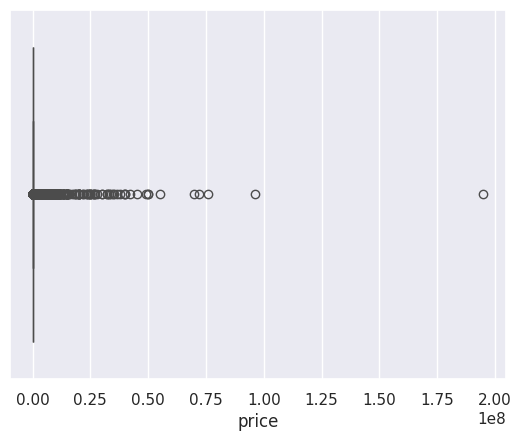

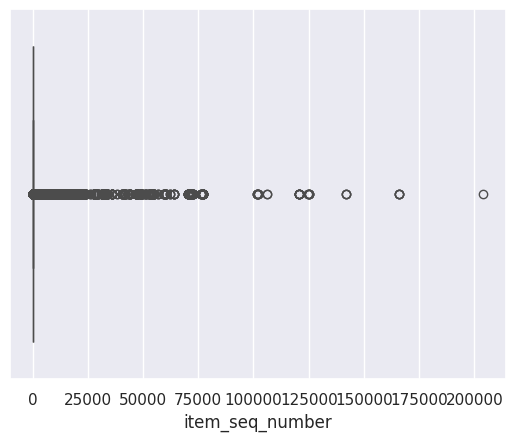

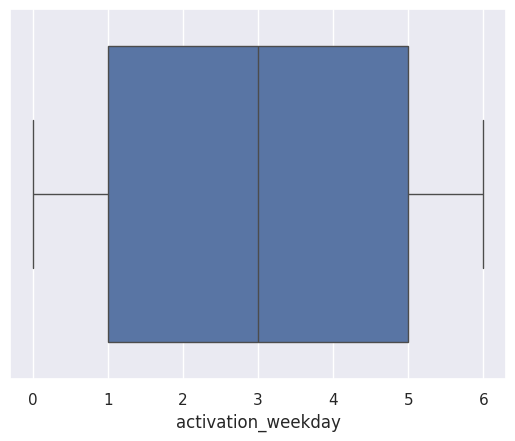

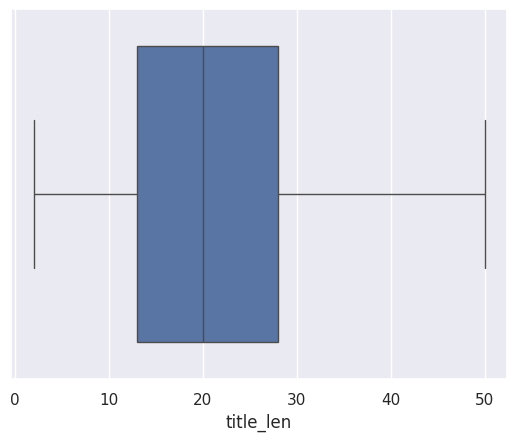

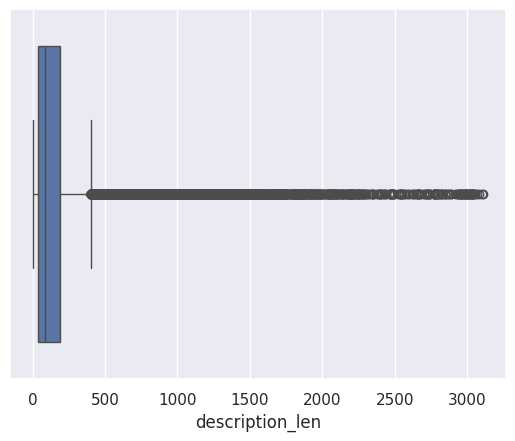

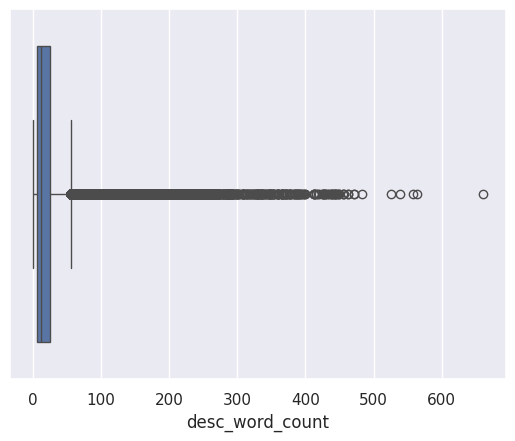

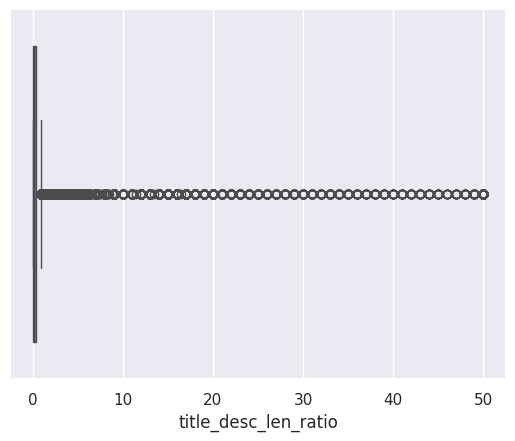

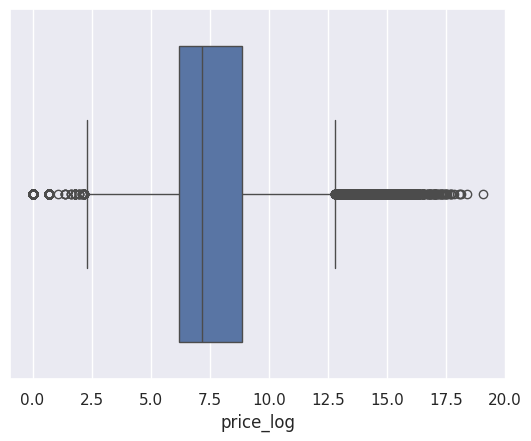

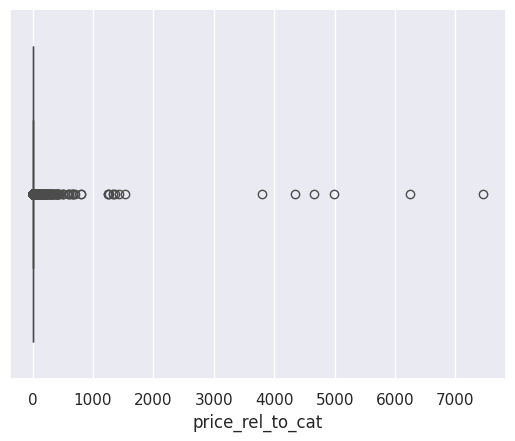

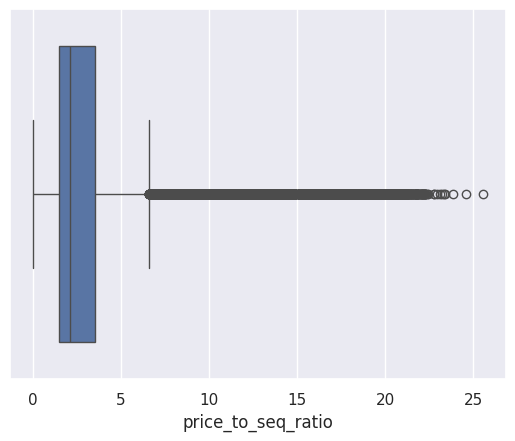

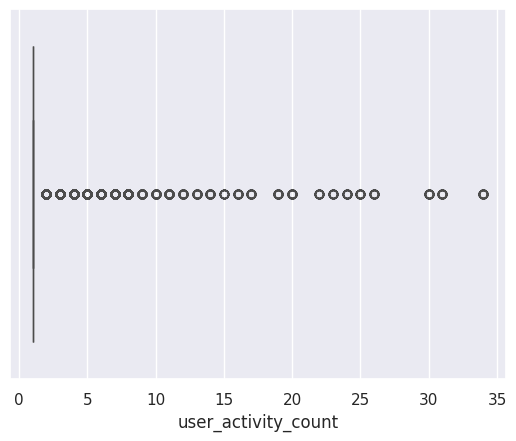

In [ ]:
for i in data_knn.columns:
    if data_knn[i].dtype !=object and data_knn[i].nunique() > 2 and i != 'deal_probability':
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [ ]:
q1=data_knn.quantile(0.25, numeric_only=True)
q3=data_knn.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

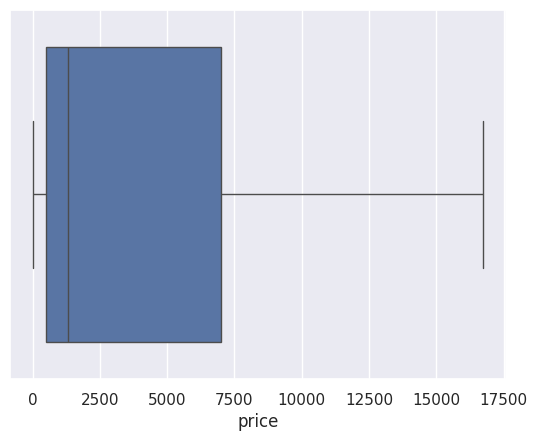

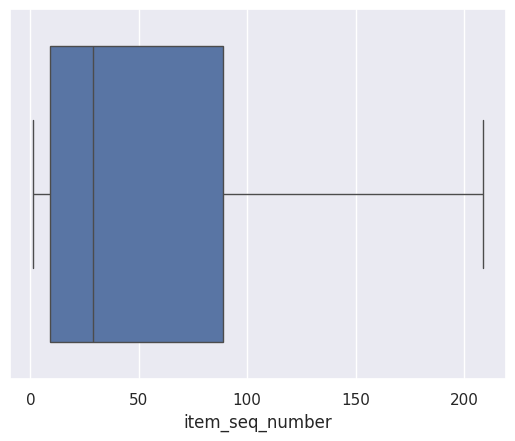

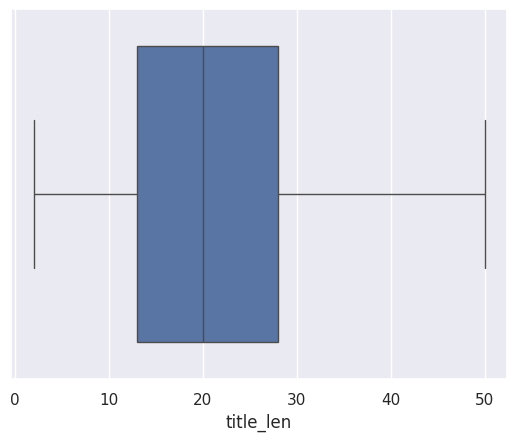

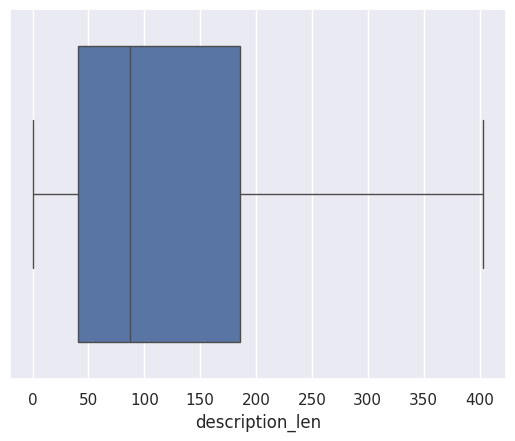

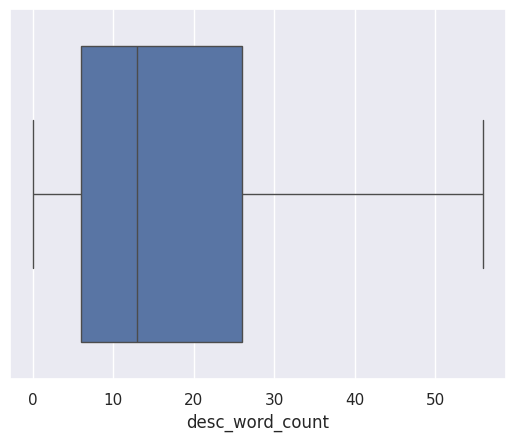

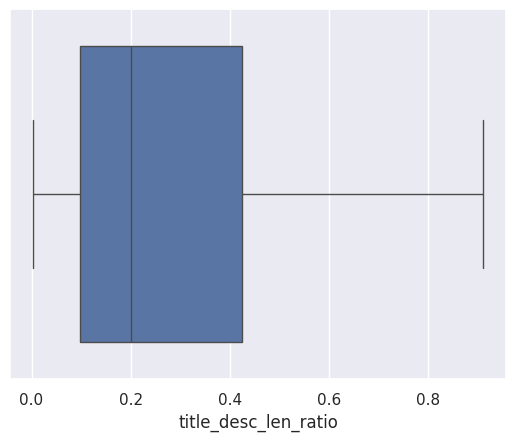

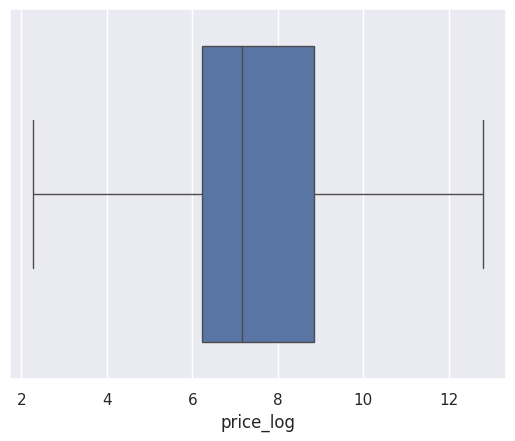

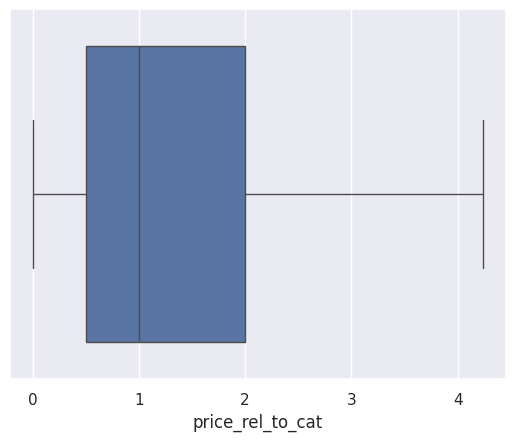

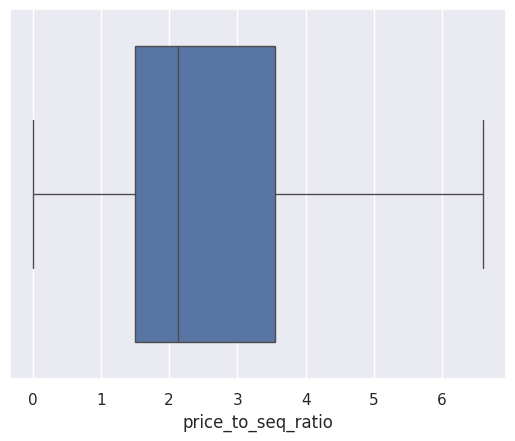

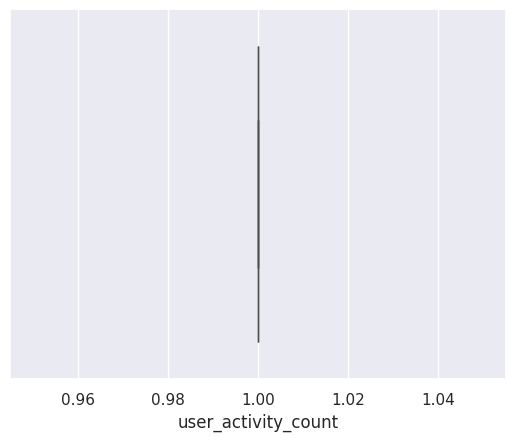

In [ ]:
for i in data_knn.columns:
    if data_knn[i].dtype in [int, float] and data_knn[i].nunique() > 2 and i != 'deal_probability':
        data_knn[i] = np.where(data_knn[i] > Upper[i],Upper[i],data_knn[i])
        data_knn[i] = np.where(data_knn[i] < Lower[i],Lower[i],data_knn[i])
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [ ]:
data_knn_for_vif = data_knn.copy()

### KNN VIF/Correlation

In [ ]:
for i in data_knn_for_vif.columns:

    if data_knn_for_vif[i].dtype in ['int64', 'float64']:

        kstest_statistic, kstest_p_value = stats.kstest(data_knn_for_vif[i], 'norm')


        print(f'Column: {i}')
        print(f'p-value: {kstest_p_value}')

        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: price
p-value: 0.0
Data does not look normally distributed

Column: item_seq_number
p-value: 0.0
Data does not look normally distributed

Column: deal_probability
p-value: 0.0
Data does not look normally distributed

Column: is_weekend
p-value: 0.0
Data does not look normally distributed

Column: title_len
p-value: 0.0
Data does not look normally distributed

Column: description_len
p-value: 0.0
Data does not look normally distributed

Column: desc_word_count
p-value: 0.0
Data does not look normally distributed

Column: title_desc_len_ratio
p-value: 0.0
Data does not look normally distributed

Column: price_log
p-value: 0.0
Data does not look normally distributed

Column: price_rel_to_cat
p-value: 0.0
Data does not look normally distributed

Column: price_to_seq_ratio
p-value: 0.0
Data does not look normally distributed

Column: user_activity_count
p-value: 0.0
Data does not look normally distributed



In [ ]:
def target_correlation(data_knn_for_vif, target, threshold=0.1):

    corr = data_knn_for_vif.corr(numeric_only=True, method='spearman')[target].drop(target)

    corr = corr[corr.abs() >= threshold]

    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    return corr.reset_index().rename(
        columns={"index": "Variable", target: "Correlation with Target"}
    )

In [ ]:
target_result = target_correlation(data_knn_for_vif, 'deal_probability')

target_result

,Variable,Correlation with Target
0,price_to_seq_ratio,0.223545
1,price_log,0.193564
2,price,0.191945
3,item_seq_number,-0.166722
4,description_len,0.109450


In [ ]:
def intercorrelation(data_knn_for_vif, target, threshold=0.7):

    corr_matrix = data_knn_for_vif.drop(columns=[target]).corr(numeric_only=True, method='spearman')

    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

    high_corr = corr_matrix.where(mask).stack().reset_index()

    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]

    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]

    return high_corr.reset_index(drop=True)

In [ ]:
intercorrelated_result = intercorrelation(data_knn_for_vif, 'deal_probability')

intercorrelated_result

,Variable 1,Variable 2,Correlation
0,price,price_log,0.997587
1,item_seq_number,price_to_seq_ratio,-0.854325
2,activation_weekday,is_weekend,0.786833
3,description_len,desc_word_count,0.986261
4,description_len,title_desc_len_ratio,-0.860633
5,desc_word_count,title_desc_len_ratio,-0.852913


In [ ]:
def calculate_vif(data_knn_for_vif, variables):
    vif_data = data_knn_for_vif[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data_knn_for_vif, [
                                                'price',
                                                'price_to_seq_ratio',
                                                # 'price_log',
                                                'item_seq_number',
                                             'description_len',
                                        ])

vif_result

,VIF,Features
0,2.304778,price
1,2.299257,price_to_seq_ratio
2,1.613260,item_seq_number
3,2.477392,description_len


In [ ]:
data_knn_for_vif = data_knn_for_vif.drop(['price_log'], axis = 1)
data_knn_for_vif.columns

Index(['region', 'city', 'parent_category_name', 'category_name', 'param_1',
       'param_2', 'param_3', 'price', 'item_seq_number', 'user_type',
       'deal_probability', 'activation_weekday', 'is_weekend', 'title_len',
       'description_len', 'desc_word_count', 'title_desc_len_ratio',
       'price_rel_to_cat', 'price_to_seq_ratio', 'user_activity_count'],
      dtype='object')

In [ ]:
data_knn_for_vif.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
region,50000,28,Краснодарский край,4825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,50000,55,Other,10738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category_name,50000,9,Личные вещи,23271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,50000,47,"Одежда, обувь, аксессуары",9364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_1,50000,48,Other,8564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_2,50000,28,Unknown,21637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_3,50000,37,Unknown,28598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,50000.0,NaN,NaN,NaN,4794.06119,6259.011323,0.0,500.0,1300.0,7000.0,16750.0
item_seq_number,50000.0,NaN,NaN,NaN,61.623,71.072439,1.0,9.0,29.0,89.0,209.0
user_type,50000,3,Private,35706,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No extra preprocessing step is needed for RF and Boosting models, so we are gonna carry out conversion and scaling processes.

## Categorical Conversion

In [ ]:
for df in [data_knn, data_knn_for_vif, data_rf_boosting, data_rf_boosting_for_pca]:
  for i in df.select_dtypes(include=['object']).columns:
      le = LabelEncoder()
      df[i] = le.fit_transform(df[i])

### Scaling and Target/Inputs Splitting

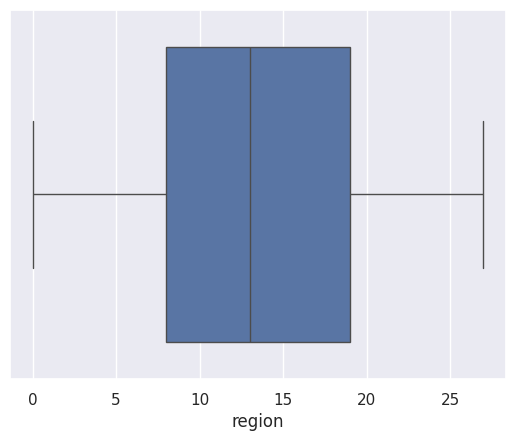

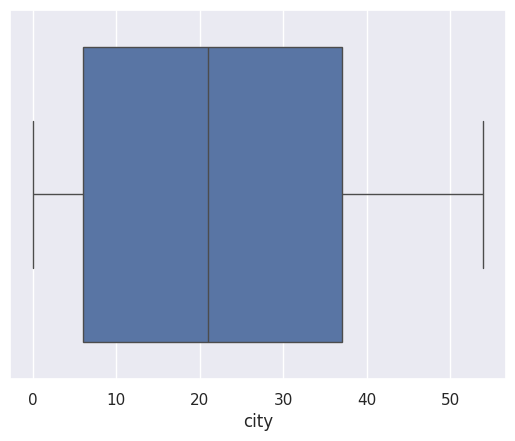

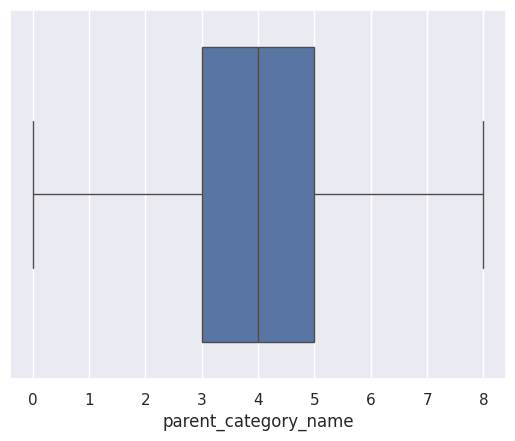

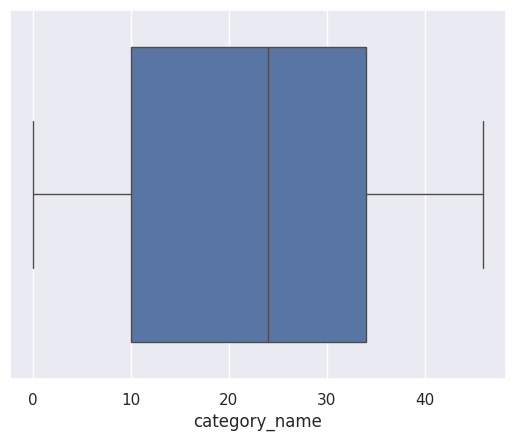

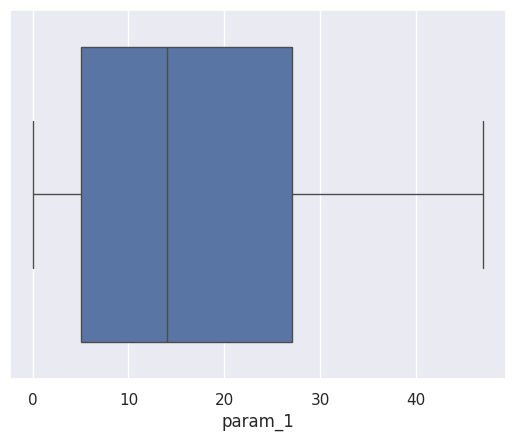

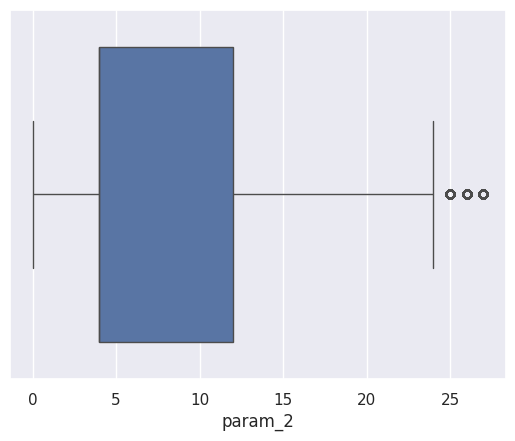

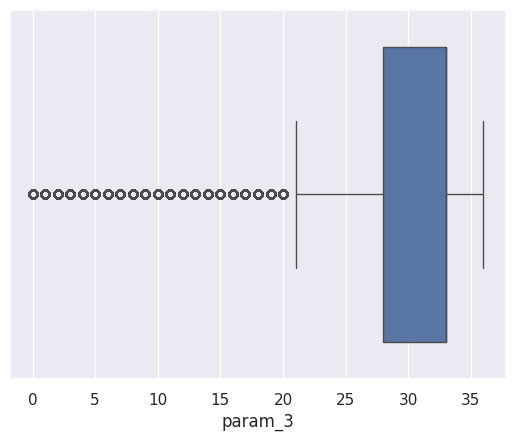

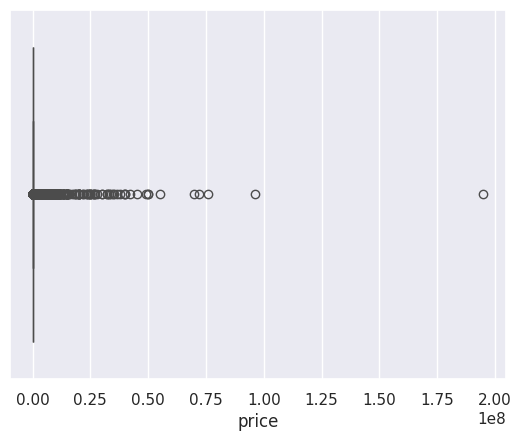

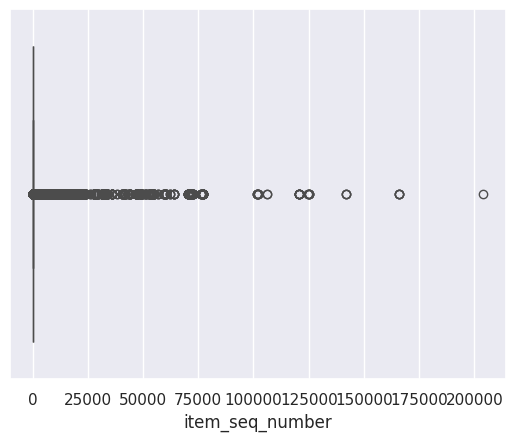

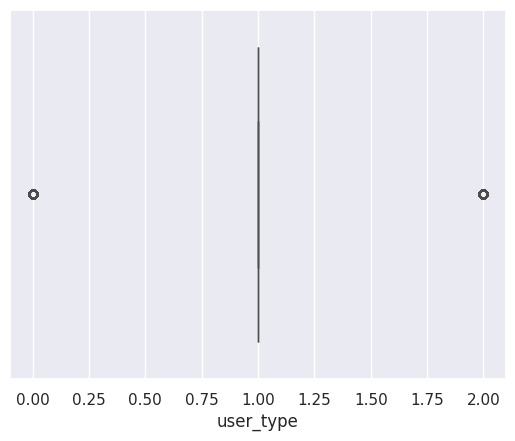

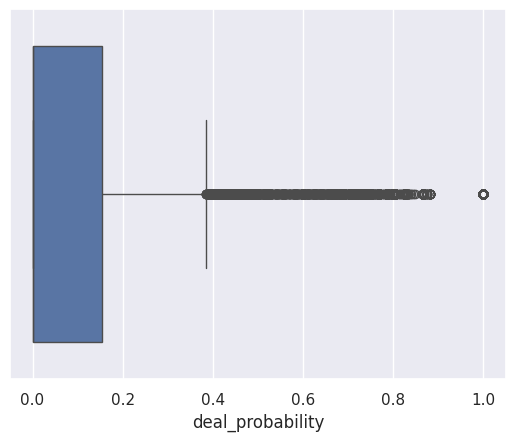

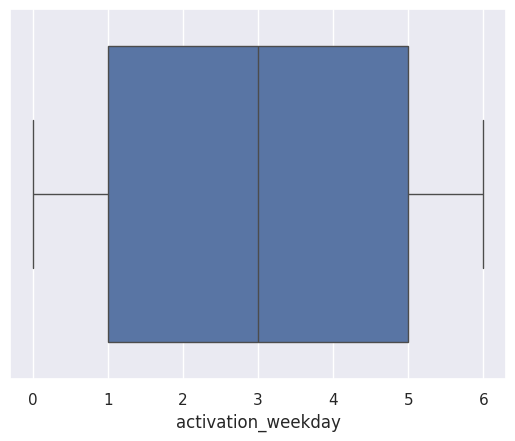

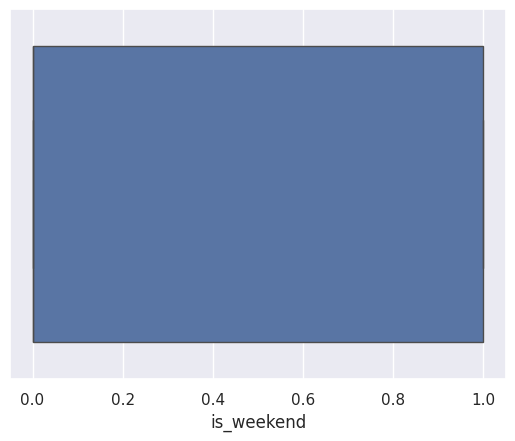

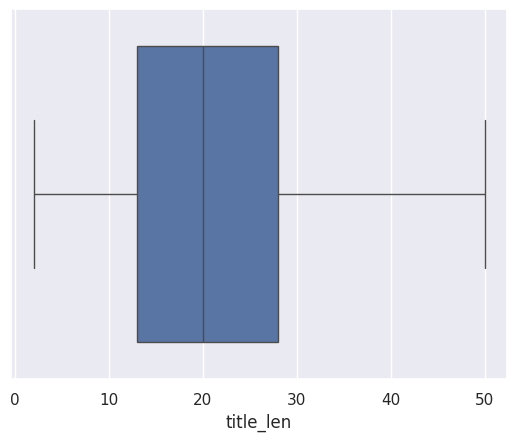

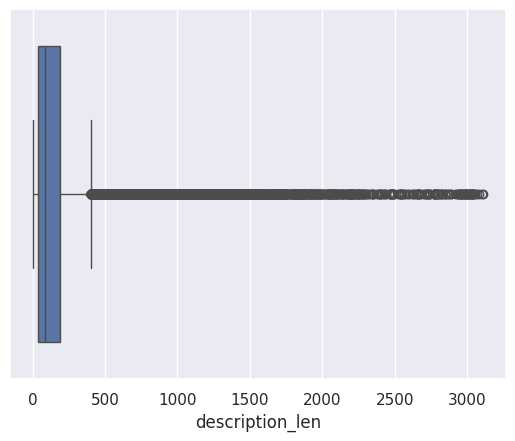

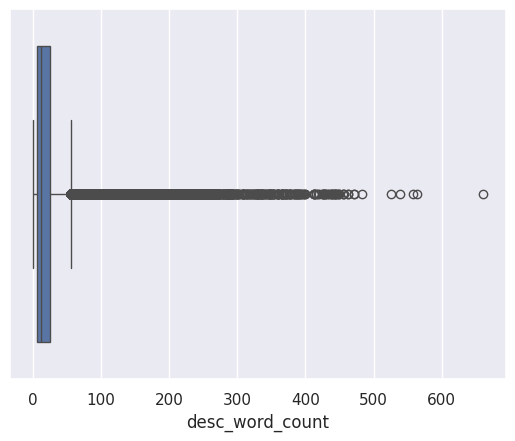

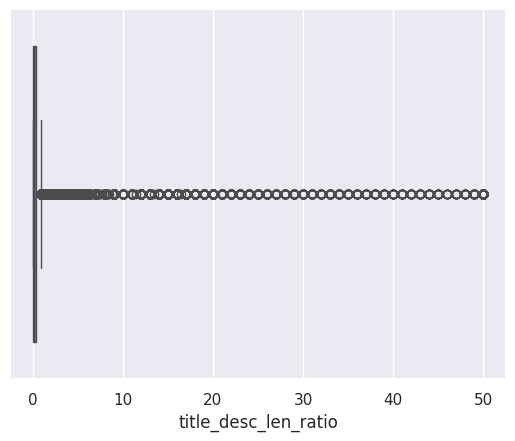

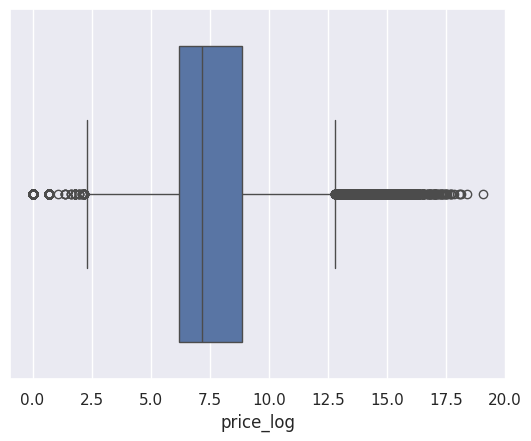

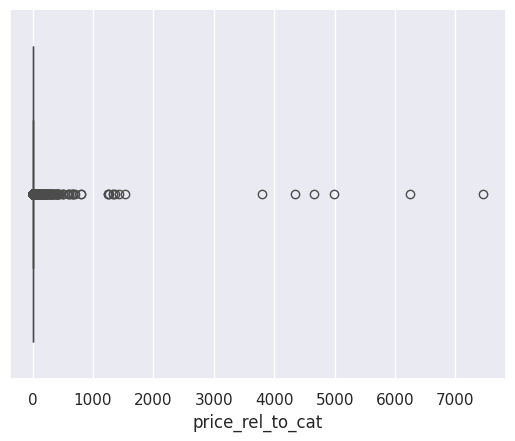

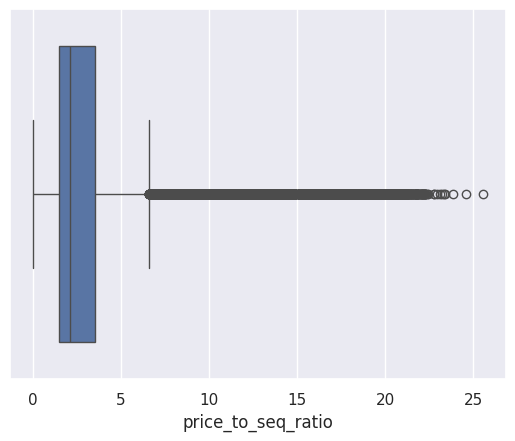

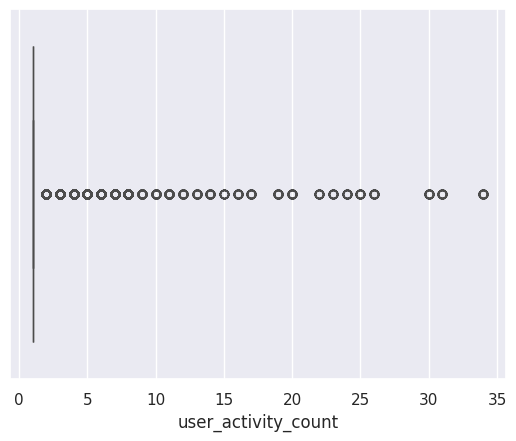

In [ ]:
# Treating outliers for PCA for tree-based models

for i in data_rf_boosting_for_pca.columns:
    sns.boxplot(data=data_rf_boosting_for_pca,x=data_rf_boosting_for_pca[i])
    plt.show()

In [ ]:
q1=data_rf_boosting_for_pca.quantile(0.25, numeric_only=True)
q3=data_rf_boosting_for_pca.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

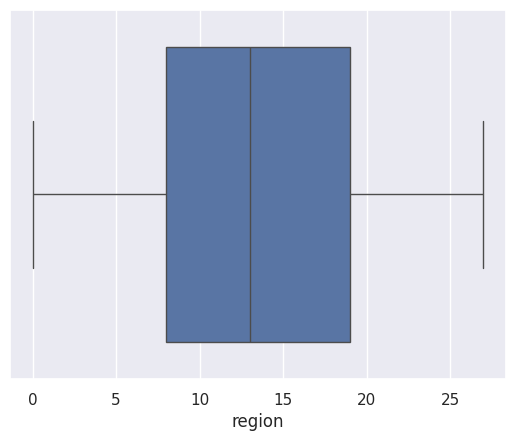

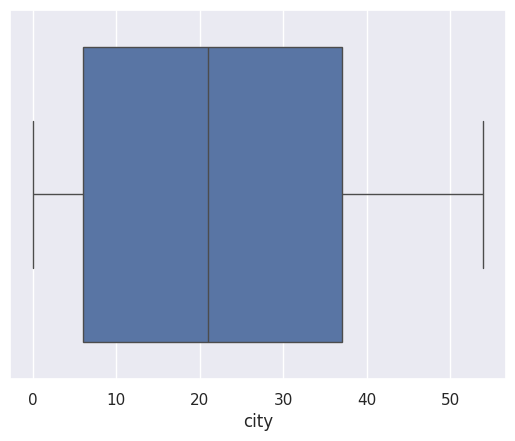

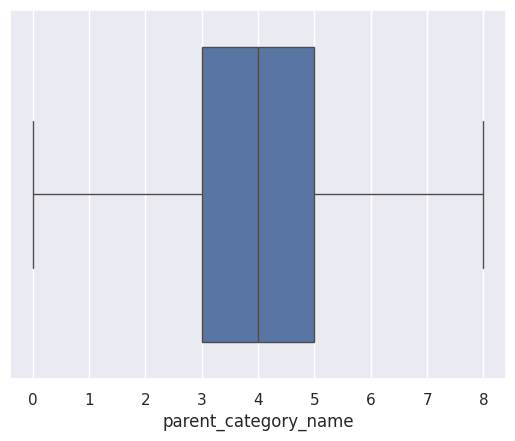

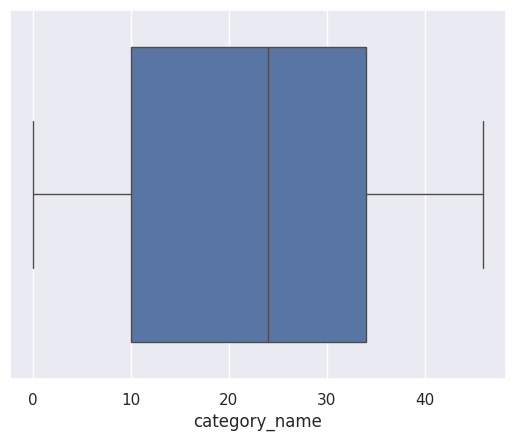

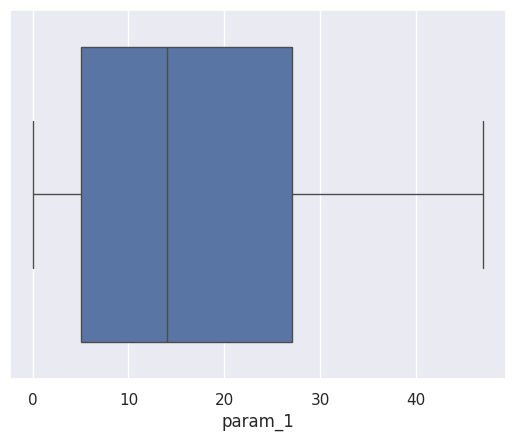

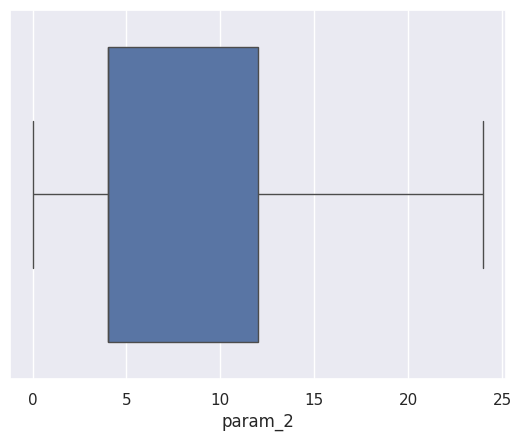

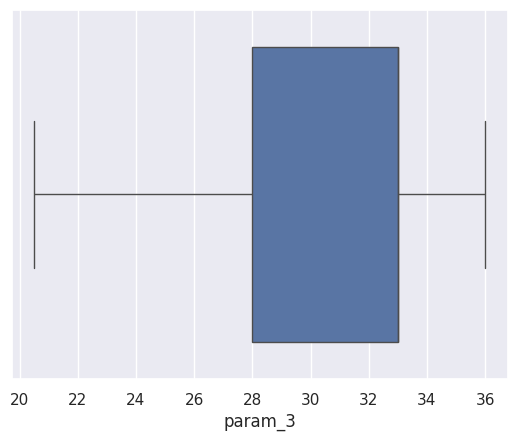

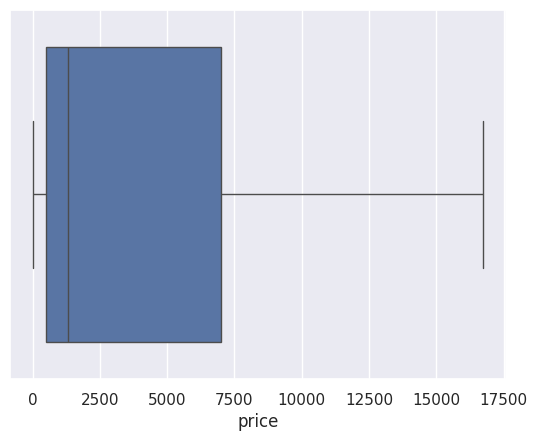

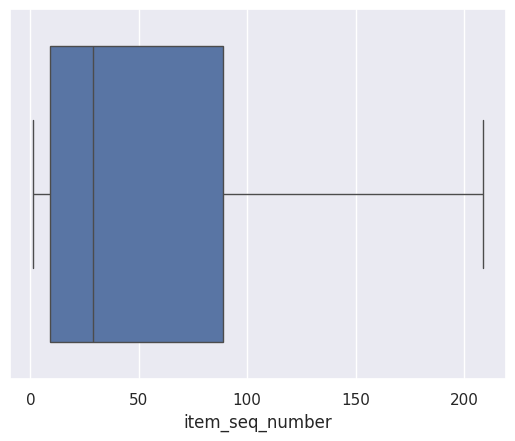

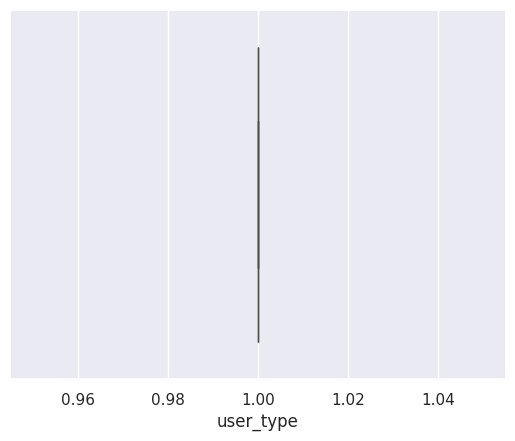

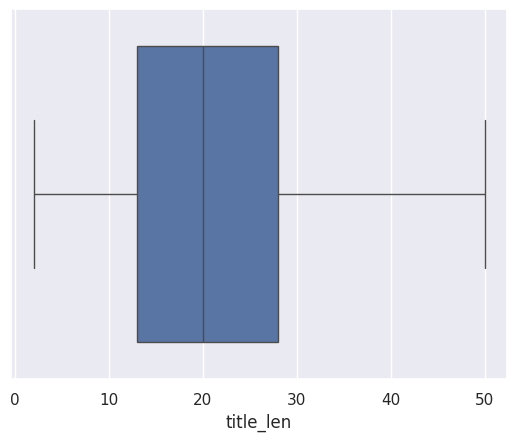

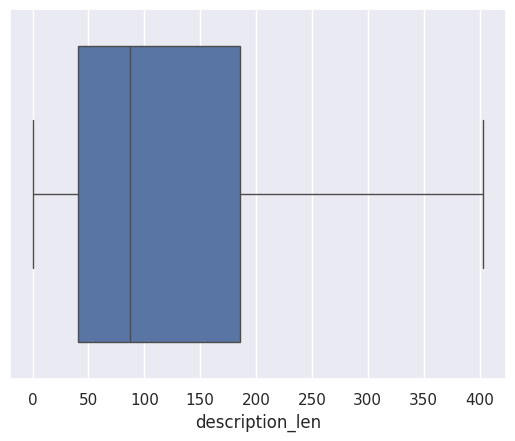

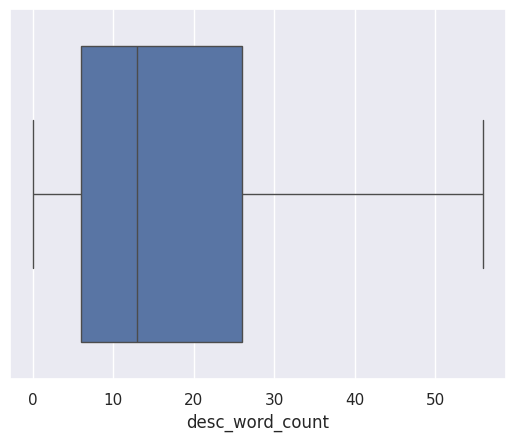

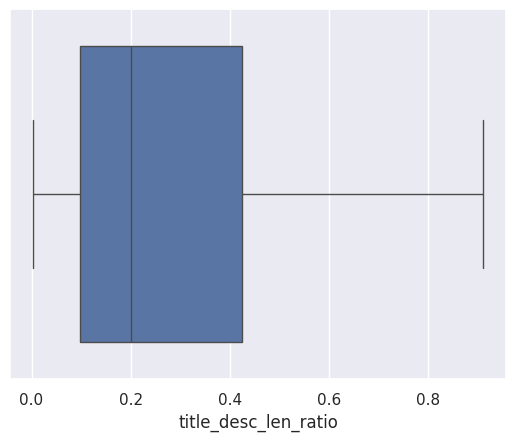

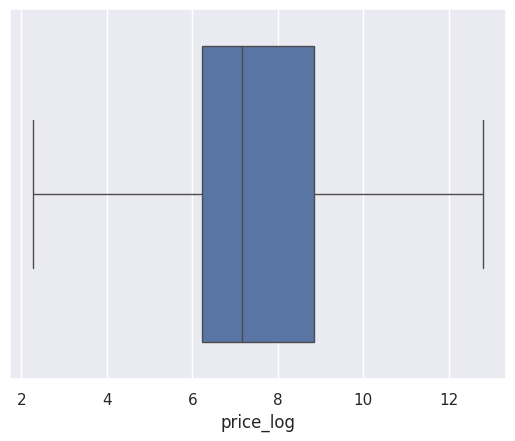

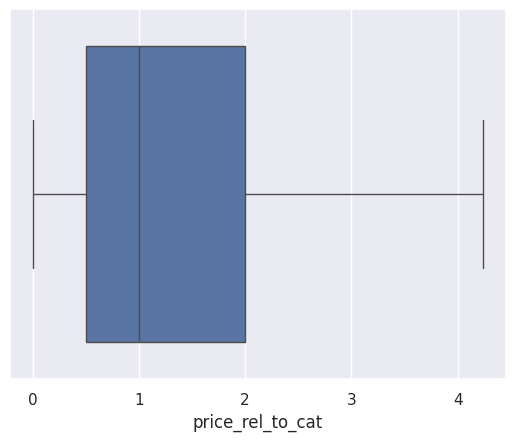

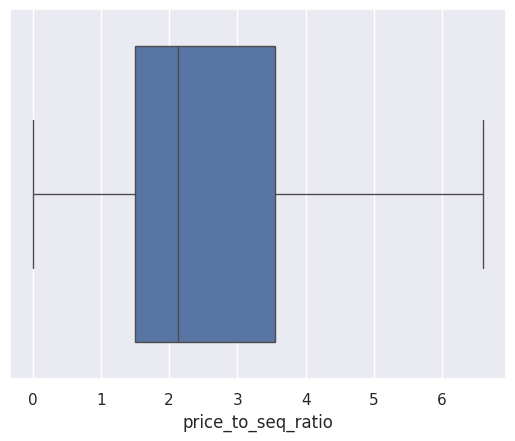

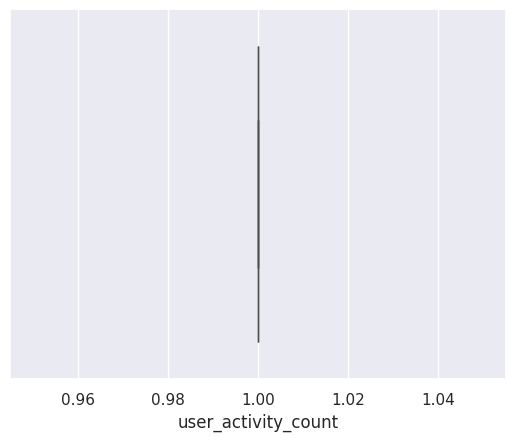

In [ ]:
for i in data_rf_boosting_for_pca.columns:
    if data_rf_boosting_for_pca[i].dtype in [int, float] and data_rf_boosting_for_pca[i].nunique() > 2 and  i != 'deal_probability':
        data_rf_boosting_for_pca[i] = np.where(data_rf_boosting_for_pca[i] > Upper[i],Upper[i], data_rf_boosting_for_pca[i])
        data_rf_boosting_for_pca[i] = np.where(data_rf_boosting_for_pca[i] < Lower[i],Lower[i], data_rf_boosting_for_pca[i])
        sns.boxplot(data=data_rf_boosting_for_pca, x=data_rf_boosting_for_pca[i])
        plt.show()

In [ ]:
scaler = StandardScaler()

# Mapping of dataset keys to their source DataFrames
data_map = {
    'knn_vif': data_knn_for_vif,
    'knn': data_knn,
    'rf_boosting': data_rf_boosting,
    'rf_boosting_pca': data_rf_boosting_for_pca,
    'cat': data_cat
}

# Loop to automate Target/Input splitting and scaling
for name, df in data_map.items():
    # 1. Target Splitting
    globals()[f"targets_{name}"] = df['deal_probability']

    # 2. Input Splitting
    # For 'rf_boosting_pca', we use a specific variable name for the drop result to match your requirements
    if name == 'rf_boosting_pca':
        inputs_rf_boosting_for_scaling = df.drop(['deal_probability'], axis=1)
        globals()["inputs_rf_boosting_for_scaling"] = inputs_rf_boosting_for_scaling
    else:
        globals()[f"inputs_{name}"] = df.drop(['deal_probability'], axis=1)

    # 3. Scaling
    if name in ['knn_vif', 'knn', 'rf_boosting_pca']:
        current_inputs = globals()["inputs_rf_boosting_for_scaling"] if name == 'rf_boosting_pca' else globals()[f"inputs_{name}"]

        scaled_array = scaler.fit_transform(current_inputs)
        globals()[f"inputs_scaled_{name}"] = scaled_array
        globals()[f"data_scaled_{name}"] = pd.DataFrame(scaled_array, columns=current_inputs.columns)


#### PCA for KNN

In [ ]:
pca_knn = PCA()

pca_knn.fit(data_scaled_knn)

PCA()

Text(0, 0.5, 'Cumulative Explained Variance')

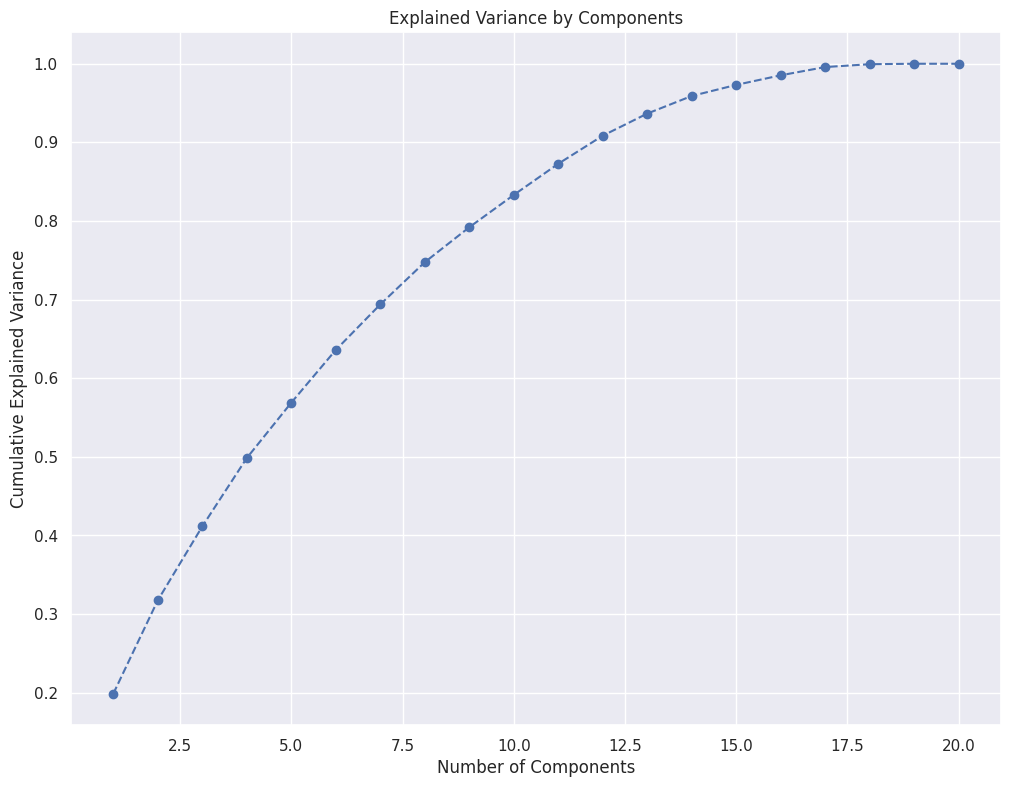

In [ ]:
# Plot the cumulative variance explained by total number of components.
# On this graph we choose the subset of components we want to keep.

# BEST PRACTICE around 80 % of the explained variance.
plt.figure(figsize = (12,9))
plt.plot(range(1,data_scaled_knn.shape[1]+1), pca_knn.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [ ]:
pca_knn = PCA(n_components = 10)

In [ ]:
pca_knn.fit(data_scaled_knn)

PCA(n_components=10)

In [ ]:
df_pca_comp_knn = pd.DataFrame(data = pca_knn.components_,
                           columns = data_scaled_knn.columns.values,
                           index = [f'Component {i}' for i in range(1, 11)])
df_pca_comp_knn

,region,city,parent_category_name,category_name,param_1,param_2,param_3,price,item_seq_number,user_type,activation_weekday,is_weekend,title_len,description_len,desc_word_count,title_desc_len_ratio,price_log,price_rel_to_cat,price_to_seq_ratio,user_activity_count
Component 1,-0.002327,-0.002055,0.064045,-0.069453,0.177476,-0.206915,0.190276,0.408006,0.061912,0.037304,-0.050839,-0.059305,0.179660,0.402685,0.396388,-0.293271,0.413120,0.233204,0.200340,0.0
Component 2,-0.043056,-0.177682,0.163449,-0.194052,0.221810,0.016325,-0.014499,0.257940,-0.406355,0.117904,0.084630,0.090302,-0.169168,-0.322110,-0.330731,0.226228,0.270691,0.084214,0.467280,-0.0
Component 3,0.026435,0.028665,-0.046463,0.033095,-0.044141,-0.017451,0.004064,-0.019294,0.000540,0.002807,0.697001,0.695175,0.019644,0.087095,0.089398,-0.081821,-0.019346,0.020205,-0.007545,0.0
Component 4,-0.019291,-0.060493,-0.367172,0.509499,-0.224673,-0.451893,0.465410,-0.058532,-0.200836,0.073022,-0.024029,-0.020241,0.085496,-0.079893,-0.079121,0.139382,-0.051248,0.109273,0.162004,0.0
Component 5,-0.014997,-0.004684,0.018698,-0.078889,0.116045,-0.179979,0.164750,0.221249,0.487757,-0.483773,0.059364,0.051216,0.176954,-0.218400,-0.225059,0.375774,0.211928,0.113954,-0.253711,0.0
Component 6,0.717741,0.664997,0.007461,-0.013115,-0.000289,-0.013828,-0.005353,0.037630,-0.062723,0.070638,-0.016023,-0.012969,0.032901,-0.062071,-0.061902,0.086230,0.042981,0.095525,0.065112,-0.0
Component 7,-0.073673,-0.003987,-0.427457,-0.013423,-0.424440,0.285475,-0.337280,0.125314,0.026059,-0.114333,-0.021491,-0.023328,-0.098938,-0.042154,-0.034127,-0.044446,0.139001,0.607684,0.049861,0.0
Component 8,-0.086652,-0.037870,0.086271,-0.043169,-0.064288,0.149782,-0.154711,-0.066347,-0.060980,0.324152,0.008612,0.006772,0.790027,0.067722,0.064320,0.411610,-0.057658,0.102408,0.042818,-0.0
Component 9,-0.022051,-0.013257,-0.384617,-0.227804,0.065145,-0.072196,0.067980,0.148548,0.324831,0.714879,0.015871,0.011866,-0.178128,-0.085249,-0.080840,0.064906,0.141265,-0.116646,-0.251201,-0.0
Component 10,-0.188272,0.165301,0.179156,0.609143,0.522199,0.136788,-0.146740,-0.041066,0.127805,0.196617,0.008772,0.014187,-0.111717,-0.053702,-0.058652,-0.010507,-0.004644,0.362373,-0.118042,-0.0


In [ ]:
scores_pca_knn = pca_knn.transform(data_scaled_knn)

scores_pca_knn

array([[ 1.88689384,  2.18367429, -1.14665237, ..., -0.91313506,
        -1.18576708,  1.67842108],
       [-3.10251091, -0.62698024,  1.7083284 , ..., -0.03654474,
         0.64908323, -0.12672997],
       [-1.29215481, -0.72309985, -0.39371845, ...,  1.19743951,
        -0.1174569 ,  0.22359569],
       ...,
       [ 1.72219405, -3.38929608, -0.54663747, ...,  0.25955598,
         1.76899003,  0.93621087],
       [-0.10194937, -0.53783481, -1.32749345, ..., -1.13428901,
         0.74766116,  1.13970128],
       [-1.9871087 , -0.77312521, -0.73343571, ..., -0.39793074,
         0.56263835, -2.02662842]])

In [ ]:
pca_df_knn = pd.DataFrame(scores_pca_knn, columns=[f'Variable_{i+1}' for i in range(scores_pca_knn.shape[1])])

pca_df_knn

,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10
0,1.886894,2.183674,-1.146652,0.717678,-0.787695,0.958819,-0.035870,-0.913135,-1.185767,1.678421
1,-3.102511,-0.626980,1.708328,-2.434626,-0.347384,2.305917,0.118391,-0.036545,0.649083,-0.126730
2,-1.292155,-0.723100,-0.393718,-2.232779,-1.256901,-0.215842,1.087654,1.197440,-0.117457,0.223596
3,-1.301527,-1.133052,-1.039770,-2.085485,0.049173,0.972200,0.924797,-0.723294,-1.060321,-0.922120
4,-2.229815,0.406110,-0.925884,-1.056326,-1.375457,0.209837,0.336893,-0.067883,-0.218499,0.414171
...,...,...,...,...,...,...,...,...,...,...
49995,-1.028112,0.674670,-0.613448,1.960685,0.177051,-1.786284,-0.455133,0.858578,0.254657,0.459820
49996,-1.750320,-0.233103,-0.361820,0.079533,1.095472,0.509235,-2.529839,2.974192,-0.672746,-0.453058
49997,1.722194,-3.389296,-0.546637,0.321282,-1.447716,0.067885,-1.395288,0.259556,1.768990,0.936211
49998,-0.101949,-0.537835,-1.327493,2.070240,-0.597680,-1.205863,0.621465,-1.134289,0.747661,1.139701


#### PCA for RF and Boosting models

In [ ]:
pca_rf_boosting = PCA()

pca_rf_boosting.fit(data_scaled_rf_boosting_pca)

PCA()

Text(0, 0.5, 'Cumulative Explained Variance')

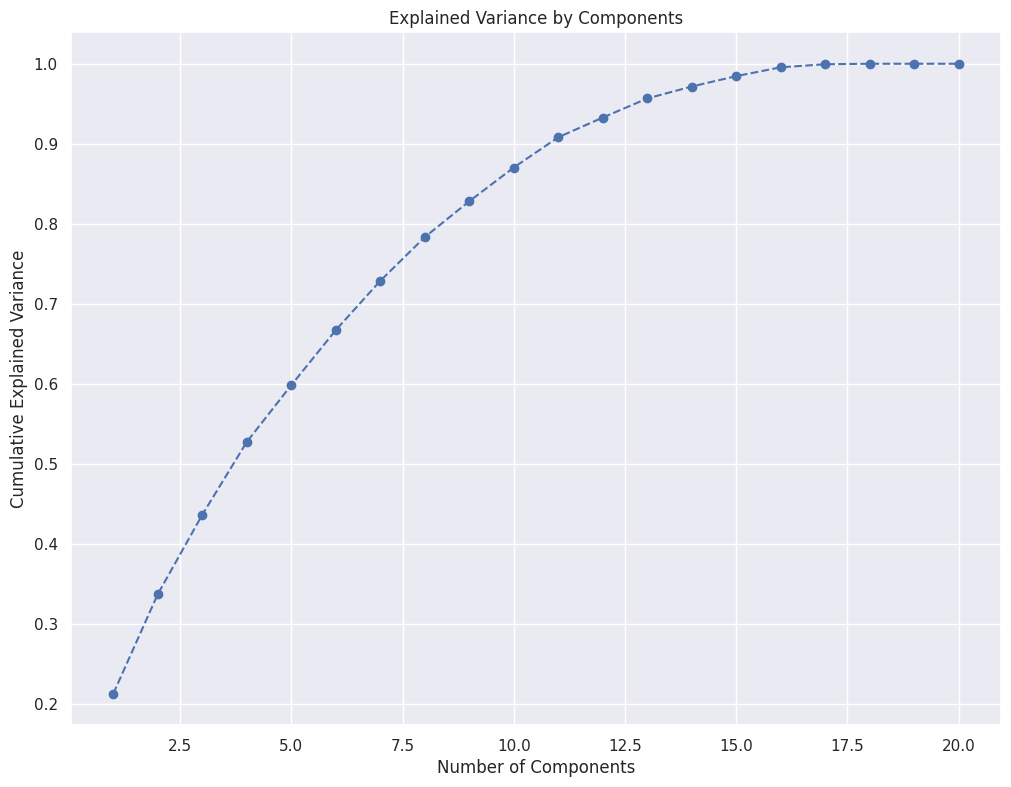

In [ ]:
# Plot the cumulative variance explained by total number of components.
# On this graph we choose the subset of components we want to keep.

# BEST PRACTICE around 80 % of the explained variance.
plt.figure(figsize = (12,9))
plt.plot(range(1, data_scaled_rf_boosting_pca.shape[1]+1), pca_rf_boosting.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [ ]:
pca_rf_boosting = PCA(n_components = 9)

In [ ]:
pca_rf_boosting.fit(data_scaled_rf_boosting_pca)

PCA(n_components=9)

In [ ]:
df_pca_comp_rf_boosting = pd.DataFrame(data = pca_rf_boosting.components_,
                           columns = data_scaled_rf_boosting_pca.columns.values,
                           index = [f'Component {i}' for i in range(1, 10)])
df_pca_comp_rf_boosting

,region,city,parent_category_name,category_name,param_1,param_2,param_3,price,item_seq_number,user_type,activation_weekday,is_weekend,title_len,description_len,desc_word_count,title_desc_len_ratio,price_log,price_rel_to_cat,price_to_seq_ratio,user_activity_count
Component 1,-0.002801,-0.002855,0.060227,-0.069001,0.174043,-0.215413,0.232762,0.404977,0.065497,0.000000e+00,-0.049764,-0.058209,0.182035,0.398778,0.392407,-0.288210,0.409009,0.227290,0.195971,0.0
Component 2,-0.045355,-0.180382,0.168857,-0.201079,0.228307,0.016509,-0.010405,0.269746,-0.390655,-8.673617e-19,0.085920,0.091187,-0.168937,-0.326538,-0.335451,0.230537,0.281908,0.090085,0.463092,-0.0
Component 3,0.025742,0.026724,-0.053452,0.042037,-0.048189,-0.028519,0.020082,-0.020540,-0.002172,-1.110223e-16,0.696847,0.695100,0.021569,0.082941,0.085210,-0.076188,-0.020716,0.020143,-0.005433,0.0
Component 4,0.031531,0.076753,0.371931,-0.476768,0.223464,0.486666,-0.455095,0.048600,0.173496,1.110223e-16,0.033655,0.030060,-0.107296,0.108574,0.108816,-0.181410,0.046168,-0.086787,-0.146181,-0.0
Component 5,0.672400,0.628894,0.021031,-0.050809,0.045235,-0.073761,0.046774,0.101138,0.111258,-2.775558e-17,0.004178,0.004361,0.114246,-0.126036,-0.128183,0.219100,0.102548,0.108532,-0.036882,-0.0
Component 6,-0.242834,-0.205698,0.119592,-0.163061,0.197678,-0.170052,0.202186,0.146423,0.534295,1.561251e-17,0.064414,0.055671,0.281671,-0.157745,-0.165326,0.394422,0.131332,-0.091142,-0.349453,-0.0
Component 7,-0.136164,-0.040534,-0.383392,0.004957,-0.350729,0.265007,-0.313982,0.167387,0.182337,-5.551115e-17,-0.001772,-0.006280,0.049424,-0.075655,-0.069741,0.105603,0.184750,0.647217,-0.049663,0.0
Component 8,-0.039660,-0.019749,0.222755,0.044992,-0.044045,0.191246,-0.136339,-0.151634,-0.276243,8.326673e-17,-0.003810,-0.002940,0.778222,0.133048,0.129076,0.301815,-0.140282,0.046315,0.192496,0.0
Component 9,-0.131295,0.114646,0.266666,0.680692,0.528273,0.037847,-0.183452,-0.052905,0.084334,-5.551115e-17,0.008411,0.013815,-0.092903,-0.037402,-0.044170,-0.023642,-0.017002,0.305647,-0.067705,0.0


In [ ]:
scores_pca_rf_boosting = pca_rf_boosting.transform(data_scaled_rf_boosting_pca)

scores_pca_rf_boosting

array([[ 1.87387504,  2.15163506, -1.13791501, ..., -0.34102977,
        -0.320322  ,  1.92516921],
       [-3.1042399 , -0.69471598,  1.65767477, ..., -0.16603544,
        -0.34538304, -0.38738603],
       [-1.24703004, -0.80374822, -0.44519225, ...,  0.72893769,
         1.0164884 , -0.2055569 ],
       ...,
       [ 1.67489051, -3.67836575, -0.55468692, ..., -1.08613246,
        -0.42170554,  0.67393188],
       [-0.0677373 , -0.60386409, -1.28530764, ...,  0.46224914,
        -1.34519757,  0.98967838],
       [-1.93244716, -0.86084952, -0.72034248, ..., -1.31973058,
        -0.39105628, -2.15282868]])

In [ ]:
pca_df_rf_boosting = pd.DataFrame(scores_pca_rf_boosting, columns=[f'Variable_{i+1}' for i in range(scores_pca_rf_boosting.shape[1])])

pca_df_rf_boosting

,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9
0,1.873875,2.151635,-1.137915,-0.582417,0.568824,-1.473727,-0.341030,-0.320322,1.925169
1,-3.104240,-0.694716,1.657675,2.253048,2.171530,-0.503833,-0.166035,-0.345383,-0.387386
2,-1.247030,-0.803748,-0.445192,1.901173,-0.501593,-0.652992,0.728938,1.016488,-0.205557
3,-1.071481,-0.979725,-1.068499,1.319820,0.873129,-0.759149,0.012238,-0.442251,-0.679882
4,-2.469883,0.340570,-0.970698,1.520211,-0.273617,-1.400090,0.267677,0.324932,0.405357
...,...,...,...,...,...,...,...,...,...
49995,-0.977805,0.617283,-0.562882,-2.082910,-1.583246,0.940941,-0.150603,0.647702,0.423261
49996,-1.686765,-0.279784,-0.340924,-0.301900,1.037767,2.138760,-1.785001,2.912351,-0.324721
49997,1.674891,-3.678366,-0.554687,-0.077655,-0.145503,0.085509,-1.086132,-0.421706,0.673932
49998,-0.067737,-0.603864,-1.285308,-2.050729,-1.365679,-0.484438,0.462249,-1.345198,0.989678


### Test-Train Splitting

In [ ]:
# Define the mapping of dataset names to their respective Features and Targets
datasets = {
    "knn_vif": (data_scaled_knn_vif, targets_knn_vif),
    "knn_pca": (pca_df_knn, targets_knn),
    "rf_boosting": (inputs_rf_boosting, targets_rf_boosting),
    "rf_boosting_pca": (pca_df_rf_boosting, targets_rf_boosting),
    "cat_features": (inputs_cat, targets_cat)
}

# Dictionary to hold all split data configurations
split_data = {}

for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Store the results in a nested dictionary for easy access
    split_data[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

print(f"Successfully split and stored {len(split_data)} datasets: {list(split_data.keys())}")

Successfully split and stored 5 datasets: ['knn_vif', 'knn_pca', 'rf_boosting', 'rf_boosting_pca', 'cat_features']


# Modelling - Default

In [ ]:
def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test, **fit_params):
    try:
        # Fit the model using any provided extra parameters (like cat_features)
        model.fit(X_train, y_train, **fit_params)

        y_pred_train = model.predict(X_train)

        mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
        mse_train = metrics.mean_squared_error(y_train, y_pred_train)
        rmse_train = np.sqrt(mse_train)
        r2_train = metrics.r2_score(y_train, y_pred_train)

        y_pred_test = model.predict(X_test)

        mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
        mse_test = metrics.mean_squared_error(y_test, y_pred_test)
        rmse_test = np.sqrt(mse_test)
        r2_test = metrics.r2_score(y_test, y_pred_test)

        print(f'Model: {model_name} | Train R2: {r2_train:.4f} | Test R2: {r2_test:.4f}')

        return [r2_train, r2_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None

In [ ]:
cat_cols = data_cat.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

['region',
 'city',
 'parent_category_name',
 'category_name',
 'param_1',
 'param_2',
 'param_3',
 'user_type']

In [ ]:
models = {
'knn_model_def': KNeighborsRegressor(),
'rf_model_def': RandomForestRegressor(random_state=42),
'xgb_model_def': XGBRegressor(random_state=42),
'lgb_model_def': LGBMRegressor(random_state=42),
'catboost_model_def': CatBoostRegressor(random_state=42),
'catboost_model_custom': CatBoostRegressor(cat_features= cat_cols, random_state=42)
}

In [ ]:
r2_df = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

for data_name, data in split_data.items():
    for model_name, model in models.items():
        # Filter logic to ensure models run on appropriate datasets
        if data_name == 'cat_features' and model_name != 'catboost_model_custom':
            continue
        if model_name == 'catboost_model_custom' and data_name != 'cat_features':
            continue
        if 'knn' in model_name and 'knn' not in data_name:
            continue
        if ('rf' in model_name or 'xgb' in model_name or 'lgb' in model_name or model_name == 'catboost_model_def') and 'rf_boosting' not in data_name:
            continue

        full_name = f"{model_name}_{data_name}"
        results = train_and_evaluate_model(
            full_name,
            model,
            data['X_train'],
            data['y_train'],
            data['X_test'],
            data['y_test']
        )

        if results:
            r2_df.loc[len(r2_df)] = [full_name, results[0], results[1]]

r2_df_sorted = r2_df.sort_values(by='Test R2', ascending=False)

Model: knn_model_def_knn_vif | Train R2: 0.3306 | Test R2: -0.0333
Model: knn_model_def_knn_pca | Train R2: 0.3258 | Test R2: -0.0498
Model: rf_model_def_rf_boosting | Train R2: 0.8798 | Test R2: 0.1349
Model: xgb_model_def_rf_boosting | Train R2: 0.4490 | Test R2: 0.1412
Model: lgb_model_def_rf_boosting | Train R2: 0.2748 | Test R2: 0.1800
Learning rate set to 0.073334
0:	learn: 0.2583492	total: 30.5ms	remaining: 30.5s
1:	learn: 0.2564474	total: 36.3ms	remaining: 18.1s
2:	learn: 0.2546236	total: 42.4ms	remaining: 14.1s
3:	learn: 0.2529729	total: 49.1ms	remaining: 12.2s
4:	learn: 0.2515144	total: 55.2ms	remaining: 11s
5:	learn: 0.2503820	total: 62.8ms	remaining: 10.4s
6:	learn: 0.2493844	total: 69ms	remaining: 9.78s
7:	learn: 0.2484302	total: 74.6ms	remaining: 9.25s
8:	learn: 0.2475021	total: 80.7ms	remaining: 8.88s
9:	learn: 0.2467578	total: 87.8ms	remaining: 8.69s
10:	learn: 0.2460545	total: 94.1ms	remaining: 8.46s
11:	learn: 0.2453814	total: 100ms	remaining: 8.25s
12:	learn: 0.24486

In [ ]:
r2_df_sorted

,Model,Train R2,Test R2
10,catboost_model_custom_cat_features,0.265010,0.183588
4,lgb_model_def_rf_boosting,0.274759,0.179988
5,catboost_model_def_rf_boosting,0.341080,0.176235
3,xgb_model_def_rf_boosting,0.449042,0.141195
2,rf_model_def_rf_boosting,0.879821,0.134921
8,lgb_model_def_rf_boosting_pca,0.228213,0.122375
9,catboost_model_def_rf_boosting_pca,0.299721,0.121871
6,rf_model_def_rf_boosting_pca,0.873931,0.097099
7,xgb_model_def_rf_boosting_pca,0.420767,0.086018
0,knn_model_def_knn_vif,0.330567,-0.033315


# Optimization / Optuna

In [ ]:
def best_params_for_models(trial, model_type, feature_set):


    if model_type == 'knn':
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
            'leaf_size': trial.suggest_int('leaf_size', 10, 100),
            'p': trial.suggest_int('p', 1, 2),
            'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan'])
        }
        model = KNeighborsRegressor(**params)
        dataset_key = 'knn_pca' if feature_set == 'pca' else 'knn_vif'
        X, y = split_data[dataset_key]['X_train'], split_data[dataset_key]['y_train']

    elif model_type == 'rf':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
            'max_features': trial.suggest_float('max_features', 0.3, 0.5),
            'max_depth': trial.suggest_int('max_depth', 10, 100),
            'min_samples_split': trial.suggest_int('min_samples_split', 20, 50),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 10)
        }
        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        dataset_key = 'rf_boosting_pca' if feature_set == 'pca' else 'rf_boosting'
        X, y = split_data[dataset_key]['X_train'], split_data[dataset_key]['y_train']

    elif model_type == 'xgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            # Fraction of the training data to be randomly sampled for each boosting round (to reduce overfitting)
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            # Fraction of features (columns) to be randomly sampled for each tree (adds diversity)
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            # Controls how much gain is needed to make a split; higher = fewer splits (simpler model)
            'gamma': trial.suggest_int('gamma', 0, 10)
        }
        model = XGBRegressor(**params, random_state=42)
        dataset_key = 'rf_boosting_pca' if feature_set == 'pca' else 'rf_boosting'
        X, y = split_data[dataset_key]['X_train'], split_data[dataset_key]['y_train']

    elif model_type == 'lgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100)
        }
        model = LGBMRegressor(**params, random_state=42, verbose=-1)
        dataset_key = 'rf_boosting_pca' if feature_set == 'pca' else 'rf_boosting'
        X, y = split_data[dataset_key]['X_train'], split_data[dataset_key]['y_train']

    else: # catboost
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
            'loss_function': trial.suggest_categorical('loss_function', ['RMSE'])
        }
        model = CatBoostRegressor(**params, verbose=0)
        dataset_key = 'rf_boosting_pca' if feature_set == 'pca' else 'rf_boosting'
        X, y = split_data[dataset_key]['X_train'], split_data[dataset_key]['y_train']

    score = cross_val_score(model, X, y, cv=3, scoring='r2', n_jobs=-1).mean()
    return score

# Configuration for loops
model_configs = {
    'knn': 3,
    'rf': 3,
    'xgb': 10,
    'lgb': 3,
    'catboost': 3
}

all_results = {}
feature_sets = ['standard', 'pca'] # Define feature sets

for model_name, n_trials in model_configs.items():
    model_results = {}
    for fs in feature_sets:
        print(f"Optimizing {model_name} with {fs} features for {n_trials} trials...")
        study = optuna.create_study(direction='maximize', sampler=TPESampler())
        study.optimize(lambda trial: best_params_for_models(trial, model_name, fs), n_trials=n_trials)

        model_results[fs] = {
            'best_score': study.best_value,
            'best_params': study.best_params
        }
        print(f"Best {model_name} ({fs}) Score: {study.best_value}\n")
    all_results[model_name] = model_results

# To access specific results later:
# best_params_rf_standard = all_results['rf']['standard']['best_params']
# best_params_rf_pca = all_results['rf']['pca']['best_params']

[I 2026-05-26 16:46:36,289] A new study created in memory with name: no-name-846b5f3a-c57f-4266-91f0-6efc0023e77c


Optimizing knn with standard features for 3 trials...


[I 2026-05-26 16:47:20,448] Trial 0 finished with value: 0.13991587808850736 and parameters: {'n_neighbors': 45, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 28, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.13991587808850736.
[I 2026-05-26 16:47:36,484] Trial 1 finished with value: 0.1251554095591109 and parameters: {'n_neighbors': 22, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 43, 'p': 1, 'metric': 'minkowski'}. Best is trial 0 with value: 0.13991587808850736.
[I 2026-05-26 16:48:09,591] Trial 2 finished with value: 0.1343751439157482 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 64, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.13991587808850736.
[I 2026-05-26 16:48:09,593] A new study created in memory with name: no-name-f062b3a4-77e6-4c2f-bf7c-d5f9b3ae8711


Best knn (standard) Score: 0.13991587808850736

Optimizing knn with pca features for 3 trials...


[I 2026-05-26 16:48:28,769] Trial 0 finished with value: 0.10296016102488588 and parameters: {'n_neighbors': 34, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 68, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.10296016102488588.
[I 2026-05-26 16:48:43,660] Trial 1 finished with value: 0.09902433566318809 and parameters: {'n_neighbors': 41, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 47, 'p': 1, 'metric': 'euclidean'}. Best is trial 0 with value: 0.10296016102488588.
[I 2026-05-26 16:48:50,275] Trial 2 finished with value: 0.09931976243766842 and parameters: {'n_neighbors': 34, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 73, 'p': 1, 'metric': 'euclidean'}. Best is trial 0 with value: 0.10296016102488588.
[I 2026-05-26 16:48:50,277] A new study created in memory with name: no-name-435f8f3e-8e3e-4945-ac7f-5eba8e79dc6b


...

Best lgb (pca) Score: 0.11085608057472973

Optimizing catboost with standard features for 3 trials...


[I 2026-05-26 16:59:43,412] Trial 0 finished with value: 0.1369893682083646 and parameters: {'iterations': 372, 'learning_rate': 0.25309606007843505, 'depth': 7, 'l2_leaf_reg': 1.6690793559609156, 'loss_function': 'RMSE'}. Best is trial 0 with value: 0.1369893682083646.
[I 2026-05-26 16:59:46,982] Trial 1 finished with value: 0.17274486543949097 and parameters: {'iterations': 186, 'learning_rate': 0.2828259400128125, 'depth': 5, 'l2_leaf_reg': 5.91260262966556, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.17274486543949097.
[I 2026-05-26 16:59:51,222] Trial 2 finished with value: -0.009756206028543213 and parameters: {'iterations': 257, 'learning_rate': 0.8658659195789037, 'depth': 6, 'l2_leaf_reg': 2.818400607784373, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.17274486543949097.
[I 2026-05-26 16:59:51,226] A new study created in memory with name: no-name-0c4e47e3-497b-4b8d-bc37-4f3d35e518c6


Best catboost (standard) Score: 0.17274486543949097

Optimizing catboost with pca features for 3 trials...


[I 2026-05-26 16:59:56,345] Trial 0 finished with value: 0.07410794629625798 and parameters: {'iterations': 588, 'learning_rate': 0.5553074947914907, 'depth': 3, 'l2_leaf_reg': 7.6875873620185, 'loss_function': 'RMSE'}. Best is trial 0 with value: 0.07410794629625798.
[I 2026-05-26 16:59:59,893] Trial 1 finished with value: 0.09169964805623536 and parameters: {'iterations': 427, 'learning_rate': 0.42315400866058117, 'depth': 4, 'l2_leaf_reg': 8.599090639607718, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.09169964805623536.
[I 2026-05-26 17:01:13,960] Trial 2 finished with value: -0.2619757921095518 and parameters: {'iterations': 916, 'learning_rate': 0.8402222638180217, 'depth': 10, 'l2_leaf_reg': 2.8154421226364734, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.09169964805623536.


Best catboost (pca) Score: 0.09169964805623536



In [ ]:
def best_params_for_model(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10),
        'loss_function': trial.suggest_categorical('loss_function', ['RMSE'])
    }

    cb_custom_reg = CatBoostRegressor(**param, verbose=0)

    # Use cross_val_score while passing cat_features through fit_params
    score = cross_val_score(cb_custom_reg,
                            split_data['cat_features']['X_train'],
                            split_data['cat_features']['y_train'],
                            cv=3,
                            scoring='r2',
                            n_jobs=-1,
                            params={'cat_features': cat_cols}).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(best_params_for_model, n_trials=3)

# Add Native results to the all_results dictionary for consistency
all_results['catboost']['native'] = {
    'best_score': study.best_value,
    'best_params': study.best_params
}

print('Best trial (Native):')
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', study.best_params)

[I 2026-05-26 17:01:13,971] A new study created in memory with name: no-name-b511c692-9dc2-4767-bbee-b289b0a60d05
[I 2026-05-26 17:01:55,041] Trial 0 finished with value: 0.11327650112319372 and parameters: {'iterations': 886, 'learning_rate': 0.9904925320146529, 'depth': 3, 'l2_leaf_reg': 6.866723013226556, 'loss_function': 'RMSE'}. Best is trial 0 with value: 0.11327650112319372.
[I 2026-05-26 17:02:18,453] Trial 1 finished with value: 0.17864898823305372 and parameters: {'iterations': 373, 'learning_rate': 0.3669352037370343, 'depth': 4, 'l2_leaf_reg': 7.840384634557574, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.17864898823305372.
[I 2026-05-26 17:03:12,528] Trial 2 finished with value: -0.006401881816080331 and parameters: {'iterations': 387, 'learning_rate': 0.9352275558544758, 'depth': 7, 'l2_leaf_reg': 9.194973256245657, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.17864898823305372.


Best trial (Native):
  Value: 0.179
  Params:  {'iterations': 373, 'learning_rate': 0.3669352037370343, 'depth': 4, 'l2_leaf_reg': 7.840384634557574, 'loss_function': 'RMSE'}


In [ ]:
# Retrieve best parameters from the 'all_results' dictionary and instantiate the optimized models

models_optimized = [
    ('KNN VIF Optuna', KNeighborsRegressor(**all_results['knn']['standard']['best_params'])),
    ('KNN PCA Optuna', KNeighborsRegressor(**all_results['knn']['pca']['best_params'])),

    ('RF Standard Optuna', RandomForestRegressor(**all_results['rf']['standard']['best_params'], random_state=42, n_jobs=-1)),
    ('RF PCA Optuna', RandomForestRegressor(**all_results['rf']['pca']['best_params'], random_state=42, n_jobs=-1)),

    ('XGB Standard Optuna', XGBRegressor(**all_results['xgb']['standard']['best_params'], random_state=42)),
    ('XGB PCA Optuna', XGBRegressor(**all_results['xgb']['pca']['best_params'], random_state=42)),

    ('LGBM Standard Optuna', LGBMRegressor(**all_results['lgb']['standard']['best_params'], random_state=42, verbose=-1)),
    ('LGBM PCA Optuna', LGBMRegressor(**all_results['lgb']['pca']['best_params'], random_state=42, verbose=-1)),

    ('CatBoost Numeric Optuna', CatBoostRegressor(**all_results['catboost']['standard']['best_params'], random_state=42, verbose=0)),
    ('CatBoost PCA Optuna', CatBoostRegressor(**all_results['catboost']['pca']['best_params'], random_state=42, verbose=0)),
    ('CatBoost Native Optuna', CatBoostRegressor(**all_results['catboost']['native']['best_params'], random_state=42, verbose=0))
]

In [ ]:
r2_df_optuna = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

for model_name, model in models_optimized:
    if 'VIF' in model_name:
        data_key = 'knn_vif'
    elif 'PCA' in model_name:
        data_key = 'knn_pca' if 'KNN' in model_name else 'rf_boosting_pca'
    elif 'Native' in model_name:
        data_key = 'cat_features'
    else:
        data_key = 'rf_boosting'

    X_train = split_data[data_key]['X_train']
    y_train = split_data[data_key]['y_train']
    X_test = split_data[data_key]['X_test']
    y_test = split_data[data_key]['y_test']

    # Check if we need to pass cat_features during fitting
    fit_params = {}
    if 'Native' in model_name:
        fit_params['cat_features'] = cat_cols

    results = train_and_evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        **fit_params
    )

    if results:
        r2_df_optuna = pd.concat([r2_df_optuna, pd.DataFrame({
            'Model': [model_name],
            'Train R2': [results[0]],
            'Test R2': [results[1]]
        })], ignore_index=True)

r2_df_sorted_optuna = r2_df_optuna.sort_values(by='Test R2', ascending=False)
display(r2_df_sorted_optuna)

Model: KNN VIF Optuna | Train R2: 1.0000 | Test R2: 0.1388


/tmp/ipykernel_5641/2223620831.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_df_optuna = pd.concat([r2_df_optuna, pd.DataFrame({


Model: KNN PCA Optuna | Train R2: 0.1617 | Test R2: 0.1071
Model: RF Standard Optuna | Train R2: 0.3517 | Test R2: 0.1774
Model: RF PCA Optuna | Train R2: 0.3427 | Test R2: 0.1224
Model: XGB Standard Optuna | Train R2: 0.1892 | Test R2: 0.1681
Model: XGB PCA Optuna | Train R2: 0.0907 | Test R2: 0.0822
Model: LGBM Standard Optuna | Train R2: 0.1664 | Test R2: 0.1543
Model: LGBM PCA Optuna | Train R2: 0.1998 | Test R2: 0.1144
Model: CatBoost Numeric Optuna | Train R2: 0.2585 | Test R2: 0.1760
Model: CatBoost PCA Optuna | Train R2: 0.2695 | Test R2: 0.1069
Model: CatBoost Native Optuna | Train R2: 0.2386 | Test R2: 0.1748


,Model,Train R2,Test R2
2,RF Standard Optuna,0.351652,0.177365
8,CatBoost Numeric Optuna,0.258486,0.176044
10,CatBoost Native Optuna,0.238633,0.174849
4,XGB Standard Optuna,0.189242,0.168110
6,LGBM Standard Optuna,0.166351,0.154268
0,KNN VIF Optuna,1.000000,0.138824
3,RF PCA Optuna,0.342655,0.122410
7,LGBM PCA Optuna,0.199846,0.114351
1,KNN PCA Optuna,0.161733,0.107076
9,CatBoost PCA Optuna,0.269507,0.106890


In [ ]:
combined_results = pd.concat([r2_df_sorted, r2_df_sorted_optuna], ignore_index=True)
combined_results_sorted = combined_results.sort_values(by='Test R2', ascending=False)

display(combined_results_sorted)

,Model,Train R2,Test R2
0,catboost_model_custom_cat_features,0.265010,0.183588
1,lgb_model_def_rf_boosting,0.274759,0.179988
11,RF Standard Optuna,0.351652,0.177365
2,catboost_model_def_rf_boosting,0.341080,0.176235
12,CatBoost Numeric Optuna,0.258486,0.176044
13,CatBoost Native Optuna,0.238633,0.174849
14,XGB Standard Optuna,0.189242,0.168110
15,LGBM Standard Optuna,0.166351,0.154268
3,xgb_model_def_rf_boosting,0.449042,0.141195
16,KNN VIF Optuna,1.000000,0.138824


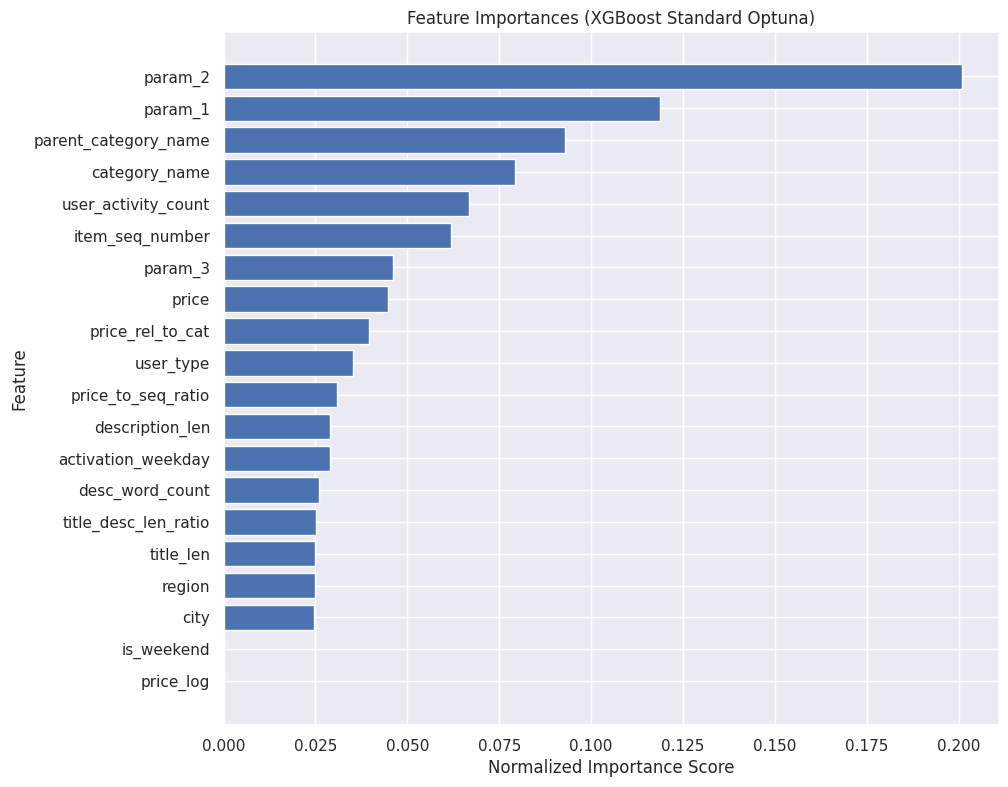

In [ ]:
# Find the XGBoost model in our optimized list
best_chosen_model = next(model for name, model in models_optimized if 'XGB Standard' in name)

# Get feature names from the corresponding training set
feature_names = split_data['rf_boosting']['X_train'].columns

# Calculate and Plot Importance
importances = best_chosen_model.feature_importances_
importances = importances / importances.sum()

importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importances (XGBoost Standard Optuna)")
plt.xlabel("Normalized Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
importance_df

,Feature,Importance
5,param_2,0.200740
4,param_1,0.118648
2,parent_category_name,0.092994
3,category_name,0.079338
19,user_activity_count,0.066797
8,item_seq_number,0.061904
6,param_3,0.046002
7,price,0.044842
17,price_rel_to_cat,0.039514
9,user_type,0.035114


In [ ]:
important_features_df = importance_df[(importance_df['Importance'] > 0.01) & (importance_df['Importance'] < 0.35)]

print("Features with Importance between 1% and 35%:")
important_features_df

Features with Importance between 1% and 35%:


,Feature,Importance
5,param_2,0.200740
4,param_1,0.118648
2,parent_category_name,0.092994
3,category_name,0.079338
19,user_activity_count,0.066797
8,item_seq_number,0.061904
6,param_3,0.046002
7,price,0.044842
17,price_rel_to_cat,0.039514
9,user_type,0.035114


SHAP Values Summary (Selected Features)


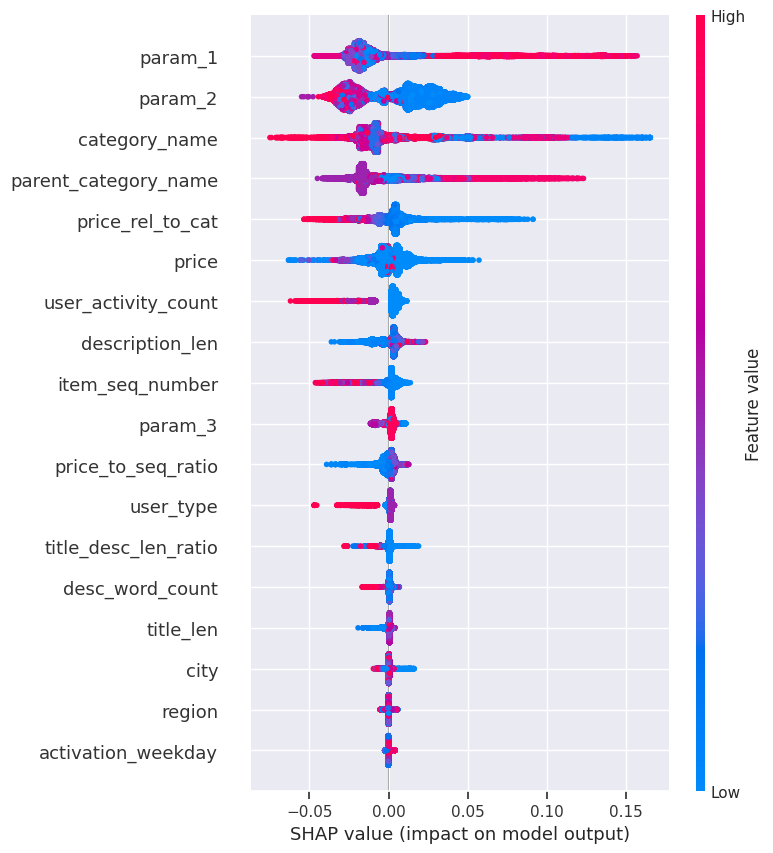

In [ ]:
selected_features = important_features_df.Feature.tolist()

explainer = shap.TreeExplainer(best_chosen_model)
shap_values = explainer.shap_values(split_data['rf_boosting']['X_train'])


shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_selected = shap_df[selected_features]
X_selected = split_data['rf_boosting']['X_train'][selected_features]


print("SHAP Values Summary (Selected Features)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_selected.values, X_selected, show=False)
plt.tight_layout()
plt.show()

In [ ]:
new_inputs = important_features_df['Feature'].tolist()

new_inputs

['param_2',
 'param_1',
 'parent_category_name',
 'category_name',
 'user_activity_count',
 'item_seq_number',
 'param_3',
 'price',
 'price_rel_to_cat',
 'user_type',
 'price_to_seq_ratio',
 'description_len',
 'activation_weekday',
 'desc_word_count',
 'title_desc_len_ratio',
 'title_len',
 'region',
 'city']

In [ ]:
fin_input = data_rf_boosting[important_features_df['Feature'].tolist()]
fin_output = data_original['deal_probability']

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(fin_input, fin_output, test_size=0.3, random_state=42)
print("Datasets prepared using selected features.")

Datasets prepared using selected features.


In [ ]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    # Use XGBRegressor for a continuous target
    xgb_reg = XGBRegressor(**param, random_state=42)

    r2 = cross_val_score(xgb_reg, X_train_fin, y_train_fin, cv=3, scoring='r2', n_jobs=-1).mean()
    return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

# Standardizing to Regressor instead of Classifier
best_chosen_model_fin = XGBRegressor(**best_params, random_state=42)

[I 2026-05-26 17:09:21,921] A new study created in memory with name: no-name-1853093c-d90f-4d70-a0f2-654e05b41fc8
[I 2026-05-26 17:09:25,325] Trial 0 finished with value: 0.12805414198562026 and parameters: {'n_estimators': 426, 'learning_rate': 0.013991142649579041, 'max_depth': 6, 'subsample': 0.6255593333397997, 'colsample_bytree': 0.5126757237406924, 'gamma': 3}. Best is trial 0 with value: 0.12805414198562026.
[I 2026-05-26 17:09:27,000] Trial 1 finished with value: 0.0896433096186429 and parameters: {'n_estimators': 645, 'learning_rate': 0.020935065565634892, 'max_depth': 3, 'subsample': 0.7160704450105775, 'colsample_bytree': 0.9783610676611008, 'gamma': 10}. Best is trial 0 with value: 0.12805414198562026.
[I 2026-05-26 17:09:29,674] Trial 2 finished with value: 0.1448228324943832 and parameters: {'n_estimators': 953, 'learning_rate': 0.020192437241148203, 'max_depth': 8, 'subsample': 0.5796523595294973, 'colsample_bytree': 0.7683793255502172, 'gamma': 2}. Best is trial 2 with 

Best trial:
  Value: 0.145
  Params:  {'n_estimators': 953, 'learning_rate': 0.020192437241148203, 'max_depth': 8, 'subsample': 0.5796523595294973, 'colsample_bytree': 0.7683793255502172, 'gamma': 2}


In [ ]:
fin_results = train_and_evaluate_model('XBG opitimized for selected features', best_chosen_model_fin, X_train_fin, y_train_fin, X_test_fin, y_test_fin)

Model: XBG opitimized for selected features | Train R2: 0.1595 | Test R2: 0.1498


In [ ]:
fin_results

[0.15949482275065807, 0.14984997711889236]

# Voting (Ensemble learning)

In [ ]:
inputs_vot = data_knn_for_vif.drop('deal_probability', axis=1)
output = data_knn_for_vif['deal_probability']

X_train_vot, X_test_vot, y_train_vot, y_test_vot = train_test_split(inputs_vot, output, test_size=0.3, random_state=42)

In [ ]:
def objective(trial, model_type):
    if model_type == 'rf':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 500),
            'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),
            'max_depth': trial.suggest_int('max_depth', 10, 50),
            'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50)
        }
        model = RandomForestRegressor(**params)

    elif model_type == 'knn':
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
            'leaf_size': trial.suggest_int('leaf_size', 10, 100),
            'p': trial.suggest_int('p', 1, 2),
            'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan'])
        }
        model = KNeighborsRegressor(**params)

    elif model_type == 'xgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_int('gamma', 0, 10)
        }
        model = XGBRegressor(**params)

    elif model_type == 'lgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100)
        }
        model = LGBMRegressor(**params)

    elif model_type == 'cb':
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
            'loss_function': trial.suggest_categorical('loss_function', ['RMSE'])
      }
        model = LGBMRegressor(**params)

    score = cross_val_score(model, X_train_vot, y_train_vot, cv=3, scoring='r2', n_jobs=-1).mean()
    return score

best_voting_models = {}
for model_name in ['rf', 'knn', 'xgb', 'lgb', 'cb']:
    print(f"Optimizing {model_name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, model_name), n_trials=5)

    best_voting_models[model_name] = study.best_params
    print(f"Best {model_name} Score: {study.best_value:.4f}")

# Instantiate best models
best_rf_vot = RandomForestRegressor(**best_voting_models['rf'], random_state=42)
best_knn_vot = KNeighborsRegressor(**best_voting_models['knn'])
best_xgb_vot = XGBRegressor(**best_voting_models['xgb'], random_state=42)
best_lgb_vot = LGBMRegressor(**best_voting_models['lgb'], random_state=42, verbose=-1)
best_cb_vot = LGBMRegressor(**best_voting_models['cb'], random_state=42, verbose=-1)

[I 2026-05-26 17:09:35,082] A new study created in memory with name: no-name-f5a762ad-585d-4dce-affb-876d43a87f95


Optimizing rf...


[I 2026-05-26 17:09:44,224] Trial 0 finished with value: 0.16977197827941962 and parameters: {'n_estimators': 126, 'max_features': 'sqrt', 'max_depth': 21, 'min_samples_split': 13, 'min_samples_leaf': 32}. Best is trial 0 with value: 0.16977197827941962.
[I 2026-05-26 17:09:59,970] Trial 1 finished with value: 0.17107947431709727 and parameters: {'n_estimators': 206, 'max_features': 'log2', 'max_depth': 31, 'min_samples_split': 114, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.17107947431709727.
[I 2026-05-26 17:10:26,762] Trial 2 finished with value: 0.1705867241875767 and parameters: {'n_estimators': 363, 'max_features': 'log2', 'max_depth': 22, 'min_samples_split': 105, 'min_samples_leaf': 18}. Best is trial 1 with value: 0.17107947431709727.
[I 2026-05-26 17:10:34,606] Trial 3 finished with value: 0.16746777532952542 and parameters: {'n_estimators': 105, 'max_features': 'log2', 'max_depth': 32, 'min_samples_split': 186, 'min_samples_leaf': 9}. Best is trial 1 with value: 0

Best rf Score: 0.1711
Optimizing knn...


[I 2026-05-26 17:10:40,716] Trial 0 finished with value: 0.054414911181035364 and parameters: {'n_neighbors': 44, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 57, 'p': 2, 'metric': 'minkowski'}. Best is trial 0 with value: 0.054414911181035364.
[I 2026-05-26 17:10:53,549] Trial 1 finished with value: 0.07849768594157291 and parameters: {'n_neighbors': 37, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}. Best is trial 1 with value: 0.07849768594157291.
[I 2026-05-26 17:10:56,241] Trial 2 finished with value: 0.032635825216013936 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 40, 'p': 2, 'metric': 'euclidean'}. Best is trial 1 with value: 0.07849768594157291.
[I 2026-05-26 17:11:09,206] Trial 3 finished with value: 0.07722431279515607 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 79, 'p': 2, 'metric': 'manhattan'}. Best is trial 1 wi

...

Best xgb Score: 0.1631
Optimizing lgb...


[I 2026-05-26 17:11:25,867] Trial 0 finished with value: -0.1539724640012113 and parameters: {'n_estimators': 670, 'learning_rate': 0.5538088609701771, 'max_depth': 9, 'num_leaves': 63}. Best is trial 0 with value: -0.1539724640012113.
[I 2026-05-26 17:11:29,542] Trial 1 finished with value: 0.12475108326744104 and parameters: {'n_estimators': 290, 'learning_rate': 0.1126702770751015, 'max_depth': 8, 'num_leaves': 94}. Best is trial 1 with value: 0.12475108326744104.
[I 2026-05-26 17:11:33,214] Trial 2 finished with value: -0.015085901529002133 and parameters: {'n_estimators': 506, 'learning_rate': 0.4376383163904809, 'max_depth': 6, 'num_leaves': 25}. Best is trial 1 with value: 0.12475108326744104.
[I 2026-05-26 17:11:37,656] Trial 3 finished with value: 0.13765240254725133 and parameters: {'n_estimators': 715, 'learning_rate': 0.08777653711581919, 'max_depth': 7, 'num_leaves': 31}. Best is trial 3 with value: 0.13765240254725133.
[I 2026-05-26 17:11:38,523] Trial 4 finished with val

Best lgb Score: 0.1441
Optimizing cb...


[I 2026-05-26 17:11:39,362] Trial 0 finished with value: 0.1119713661189623 and parameters: {'iterations': 311, 'learning_rate': 0.3678360367701247, 'depth': 10, 'l2_leaf_reg': 1.0236201396503937, 'loss_function': 'RMSE'}. Best is trial 0 with value: 0.1119713661189623.
[I 2026-05-26 17:11:40,356] Trial 1 finished with value: 0.17262474290716034 and parameters: {'iterations': 481, 'learning_rate': 0.028180897630768063, 'depth': 4, 'l2_leaf_reg': 8.249125887381508, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.17262474290716034.
[I 2026-05-26 17:11:41,102] Trial 2 finished with value: 0.1487959848306922 and parameters: {'iterations': 262, 'learning_rate': 0.23754074577305095, 'depth': 7, 'l2_leaf_reg': 3.9087540306322275, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.17262474290716034.
[I 2026-05-26 17:11:41,851] Trial 3 finished with value: 0.1589636855170492 and parameters: {'iterations': 533, 'learning_rate': 0.18766023267377388, 'depth': 4, 'l2_leaf_reg': 2.60813

Best cb Score: 0.1750


In [ ]:
voting_reg = VotingRegressor(
    estimators=[
        ('rf', best_rf_vot),
        ('knn', best_knn_vot),
        ('xgb', best_xgb_vot),
        ('lgb', best_lgb_vot),
        ('cat', best_cb_vot)
    ])

train_and_evaluate_model(model_name='Voting model', model=voting_reg, X_train=X_train_vot, y_train=y_train_vot, X_test=X_test_vot, y_test=y_test_vot)

Model: Voting model | Train R2: 0.2003 | Test R2: 0.1597


[0.20026074312168407, 0.15974443346077827]

# Stacking (Ensemble learning)

In [ ]:
estimators = [
    ('KNN Optuna', KNeighborsRegressor(**all_results['knn']['standard']['best_params'])),
    ('RF Optuna', RandomForestRegressor(**all_results['rf']['standard']['best_params'], random_state=42, n_jobs=-1)),
    ('CatBoost Optuna', CatBoostRegressor(**all_results['catboost']['standard']['best_params'], random_state=42, verbose=0)),
    ('LightGBM Optuna', LGBMRegressor(**all_results['lgb']['standard']['best_params'], random_state=42, verbose=-1)),
]


In [ ]:
stack_reg = StackingRegressor(
    estimators=estimators,
    final_estimator = XGBRegressor(**all_results['xgb']['standard']['best_params'], random_state=42),
    passthrough = True,
    cv=5,
    n_jobs = -1
)

stack_reg

StackingRegressor(cv=5,
                  estimators=[('KNN Optuna',
                               KNeighborsRegressor(algorithm='kd_tree',
                                                   leaf_size=28,
                                                   metric='manhattan',
                                                   n_neighbors=45, p=1,
                                                   weights='distance')),
                              ('RF Optuna',
                               RandomForestRegressor(max_depth=99,
                                                     max_features=0.3230000966080844,
                                                     min_samples_leaf=9,
                                                     min_samples_split=43,
                                                     n_estimators=591,
                                                     n_jobs=-1,
                                                     random_state=42)),
                              ('CatBoost Optuna',
                               CatBoost...
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.0767243692085271,
                                               max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=8,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=47, n_jobs=None,
                                               num_parallel_tree=None, ...),
                  n_jobs=-1, passthrough=True)

In [ ]:
train_and_evaluate_model('Stacking model', stack_reg, X_train_vot, y_train_vot, X_test_vot, y_test_vot)

Model: Stacking model | Train R2: 0.3179 | Test R2: 0.1788


[0.3178937126299306, 0.17882706247428648]